# MOD 01 - AndinaLog IoT Regresion Logistica

Entrena y evalua el modelo obligatorio de 03B: una **regresion logistica** que estima la
probabilidad de que una lectura de telemetria tenga una **desviacion termica durante los
proximos 60 minutos**.

- Entrada: `datos/gold/andinalog_iot_modelado_gold.csv` (solo lectura, no se modifica).
- Unidad de observacion: **una lectura de telemetria** con ventana futura evaluable.
- Variable objetivo: `desviacion_proximos_60min_flag`.
- Predictores minimos: temperatura actual, humedad actual, desviacion termica actual,
  temperatura anterior y variacion de temperatura de los ultimos 30 minutos, adaptados a
  los nombres reales de Gold.
- Split por viaje u orden con semilla fija; cada viaje queda en una sola particion.
- Todo parametro aprendido se ajusta **solo con entrenamiento**, dentro de un `Pipeline`.
- El conjunto de prueba se evalua **una sola vez**, con el modelo principal.
- Filtros siempre explicitos: nunca `dropna()` indiscriminado, nunca lectura ni escritura
  del Gold, y ninguna afirmacion de causalidad.
- El notebook no modifica Gold y exporta **un unico CSV**, el de metricas de la entrega
  en formato largo, declarado en `config['rutas']['metricas_csv']`.

In [1]:
# --- Configuracion unica y centralizada: rutas, nombres reales, constantes y parametros.
import hashlib
import os
import platform
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, confusion_matrix,
                             f1_score, fbeta_score, precision_recall_curve, precision_score,
                             recall_score, roc_auc_score, roc_curve)
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 60)
sns.set_theme(style='whitegrid')


def detectar_raiz():
    relativa = Path('datos/gold/andinalog_iot_modelado_gold.csv')
    candidatas = []
    if os.getenv('ANDINALOG_ROOT'):
        candidatas.append(Path(os.environ['ANDINALOG_ROOT']))
    cwd = Path.cwd().resolve()
    candidatas.extend([cwd, *cwd.parents])
    visitadas = set()
    for candidata in candidatas:
        normalizada = candidata.resolve()
        if normalizada in visitadas:
            continue
        visitadas.add(normalizada)
        if (normalizada / relativa).exists():
            return normalizada
    raise FileNotFoundError('No se encontro datos/gold/andinalog_iot_modelado_gold.csv')


RAIZ = detectar_raiz()

config = {
    'rutas': {
        'gold': 'datos/gold/andinalog_iot_modelado_gold.csv',
        'notebook': 'notebooks/modelado/MOD_01_AndinaLog_Regresion_Logistica.ipynb',
        'informe': 'informes/modelado/Informe_MOD_01_AndinaLog_Regresion_Logistica.md',
        'metricas_csv': 'datos/modelado/metricas_mod_01_regresion_logistica.csv',
    },
    # Nombres previstos por el prompt -> nombres reales del CSV Gold.
    'mapeo_columnas': {
        'id_lectura': ('lectura_id', '_fila_bronze'),
        'entidad': ('viaje_id', 'viaje_id'),
        'orden': ('order_id', 'order_id'),
        'timestamp': ('timestamp', 'timestamp'),
        'temp_actual': ('temperatura_actual', 'temperatura_cabina_c'),
        'humedad_actual': ('humedad_actual', 'humedad_cabina_pct'),
        'flag_actual': ('desviacion_termica_flag_actual', 'desviacion_termica_flag'),
        'temp_anterior': ('temperatura_anterior', 'temperatura_anterior'),
        'var_30min': ('variacion_temperatura_30min', 'variacion_temperatura_30min'),
        'ts_temp_anterior': ('ts_temperatura_anterior', 'ts_temperatura_anterior'),
        'ts_base_var': ('ts_base_variacion', 'ts_base_variacion'),
        'motivo_temp_anterior': ('motivo_temp_anterior', 'motivo_temperatura_anterior'),
        'motivo_var_30min': ('motivo_var_30min', 'motivo_variacion_30min'),
        'objetivo': ('desviacion_proximos_60min_flag', 'desviacion_proximos_60min_flag'),
        'ventana_evaluable': ('ventana_objetivo_evaluable', 'ventana_objetivo_evaluable'),
        'objetivo_coincide_silver': ('objetivo_coincide_con_silver',
                                     'objetivo_coincide_con_silver'),
        'calidad_estado': ('calidad_estado', 'calidad_estado'),
        'calidad_motivo': ('calidad_motivo', 'calidad_motivo'),
    },
    'identificadores': ['_fila_bronze', 'viaje_id', 'order_id', 'camion_id', 'producto_id'],
    'clave_lectura': ['viaje_id', 'timestamp'],
    'patron_entidad': r'^VIA-\d{5}$',
    # Predictores minimos: conceptos del prompt adaptados a Gold.
    'predictores_minimos': {
        'temperatura actual': 'temperatura_cabina_c',
        'humedad actual': 'humedad_cabina_pct',
        'desviacion termica actual': 'desviacion_termica_flag',
        'temperatura anterior': 'temperatura_anterior',
        'variacion de temperatura 30 min': 'variacion_temperatura_30min',
    },
    'binarias_sin_escalar': ['desviacion_termica_flag'],
    'continuas': ['temperatura_cabina_c', 'humedad_cabina_pct',
                  'temperatura_anterior', 'variacion_temperatura_30min'],
    'indicadores_ausencia': ['sin_historial_temp_anterior', 'sin_historial_var30'],
    # Decisiones aprobadas: codificacion neutral de ausencia estructural de historia.
    'motivos_estructurales': {
        'temp_anterior': ['primera_lectura_del_viaje'],
        'var_30min': ['primera_lectura_del_viaje', 'sin_lectura_en_[t-45,t-30]_minutos'],
    },
    'valor_neutro_var30': 0.0,
    # Columnas que jamas pueden entrar a X.
    'columnas_no_admisibles': [
        'desviacion_proximos_60min_flag',
        'ventana_objetivo_evaluable',
        'ts_temperatura_anterior',
        'ts_base_variacion',
        'motivo_temperatura_anterior',
        'motivo_variacion_30min',
        'objetivo_coincide_con_silver',
        'calidad_estado',
        'calidad_motivo',
        '_fila_bronze',
        'order_id',
        'camion_id',
        'producto_id',
    ],
    # Entrenamiento y prueba.
    'test_size': 0.20,
    'semilla': 20260925,
    'n_splits_validacion': 5,
    # Preprocesamiento aprendido solo con entrenamiento.
    'imputacion': {'strategy': 'median', 'add_indicator': False},
    'escalado': {'with_mean': True, 'with_std': True},
    # Modelo obligatorio.
    'logistic_regression': {
        'penalty': 'l2',
        'C': 1.0,
        'solver': 'lbfgs',
        'max_iter': 2000,
        'random_state': 20260925,
        'class_weight': 'balanced',
    },
    # Declaracion de criterios de seleccion, revisada por decision del usuario tras la
    # auditoria del 2026-09-25. No se uso el conjunto de prueba para declararlos.
    'sensibilidad': {
        'class_weight_alternativo': None,
        'variante_historia_completa': True,
        'criterio_principal': 'recall de la clase positiva',
        'restriccion_operativa': ['precision', 'volumen de falsas alertas'],
        'metrica_global_complementaria': 'PR AUC',
        'metrica_global_no_unico_criterio': True,
        'razon_de_la_decision': (
            'el falso negativo tiene mayor costo operativo en cadena de frio que una '
            'revision adicional: no alertar una desviacion futura cuesta mas que revisar '
            'de mas'),
        'modelo_principal': "class_weight='balanced'",
        'alternativa_operativa': 'class_weight=None',
        'costo_aceptado': (
            'reduccion de precision de 0.642513 a 0.287506 a cambio de recall de '
            '0.378285 a 0.455079 en validacion cruzada por grupos'),
        'pendiente': (
            'el equilibrio definitivo precision-recall requiere un costo de negocio o la '
            'confirmacion del docente'),
        'ambito_de_comparacion': 'validacion cruzada por grupos dentro de entrenamiento',
        'uso_del_conjunto_de_prueba': 'ninguno: la comparacion no se hizo sobre prueba',
    },
    'umbral_inicial': 0.5,
    'umbral_secundario_criterio': 'F2 sobre probabilidades out-of-fold de entrenamiento',
    'metricas': ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc',
                 'prevalencia', 'tn', 'fp', 'fn', 'tp'],
    'humedad_rango_valido': (0.0, 100.0),
    'visual': {
        'figsize': (11, 5.5),
        'paleta': {0: '#4C72B0', 1: '#C44E52'},
        'paleta_base': '#7F7F7F',
    },
}

PATHS = {clave: RAIZ / relativa for clave, relativa in config['rutas'].items()}
COL = {clave: real for clave, (_, real) in config['mapeo_columnas'].items()}
PRED = list(config['predictores_minimos'].values())
IND = config['indicadores_ausencia']
SEMILLA = config['semilla']
VIS = config['visual']
rng = np.random.default_rng(SEMILLA)

print('Raiz del proyecto:', RAIZ)
print('Ejecucion UTC:', datetime.now(timezone.utc).isoformat())
print('Python:', platform.python_version(), '| pandas:', pd.__version__,
      '| numpy:', np.__version__, '| scikit-learn:', sklearn.__version__,
      '| seaborn:', sns.__version__, '| matplotlib:', matplotlib.__version__)
print('Semilla declarada:', SEMILLA)
print('Rutas tomadas de config:')
for clave, ruta in PATHS.items():
    print(f'  {clave:>8}: {ruta.relative_to(RAIZ).as_posix()}')
print()
print('Mapeo prompt -> Gold (predictores minimos):')
for concepto, real in config['predictores_minimos'].items():
    print(f'  {concepto:>34} -> {real}')
print()
print('Configuracion de modelo:', config['logistic_regression'])
print('Proporcion de prueba:', config['test_size'], '| particiones de validacion:',
      config['n_splits_validacion'], '| umbral inicial:', config['umbral_inicial'])
print('Métricas a reportar:', config['metricas'])

Raiz del proyecto: C:\Users\remrodri\Github\practicasNotebookColab\proyecto-integradorV2
Ejecucion UTC: 2026-09-25T21:04:03.777296+00:00
Python: 3.13.15 | pandas: 3.0.5 | numpy: 2.5.3 | scikit-learn: 1.6.1 | seaborn: 0.13.2 | matplotlib: 3.10.0
Semilla declarada: 20260925
Rutas tomadas de config:
      gold: datos/gold/andinalog_iot_modelado_gold.csv
  notebook: notebooks/modelado/MOD_01_AndinaLog_Regresion_Logistica.ipynb
   informe: informes/modelado/Informe_MOD_01_AndinaLog_Regresion_Logistica.md
  metricas_csv: datos/modelado/metricas_mod_01_regresion_logistica.csv

Mapeo prompt -> Gold (predictores minimos):
                  temperatura actual -> temperatura_cabina_c
                      humedad actual -> humedad_cabina_pct
           desviacion termica actual -> desviacion_termica_flag
                temperatura anterior -> temperatura_anterior
     variacion de temperatura 30 min -> variacion_temperatura_30min

Configuracion de modelo: {'penalty': 'l2', 'C': 1.0, 'solver': 'l

## 1. Carga del Gold en modo solo lectura

Se lee `datos/gold/andinalog_iot_modelado_gold.csv` sin escribirlo. Se calcula el SHA-256
al inicio y se vuelve a calcular al cierre para demostrar que el Gold no cambia. Si falta
cualquier columna obligatoria, la ejecucion se detiene con un error claro.

In [2]:
# --- Carga sin modificar el archivo y validacion de columnas obligatorias.
HASH_GOLD_ENTRADA = hashlib.sha256(PATHS['gold'].read_bytes()).hexdigest()

gold = pd.read_csv(PATHS['gold'])

obligatorias = (set(COL.values()) | set(PRED)
                | set(config['columnas_no_admisibles']) | set(config['identificadores']))
faltantes = sorted(c for c in obligatorias if c not in gold.columns)
if faltantes:
    raise ValueError('Bloqueo: faltan columnas obligatorias en el Gold: ' + ', '.join(faltantes))

print('Archivo Gold (solo lectura):', PATHS['gold'].relative_to(RAIZ).as_posix())
print('SHA-256 al inicio de la ejecucion:', HASH_GOLD_ENTRADA)
print('Forma Gold:', gold.shape)
print('Columnas disponibles:')
for indice, nombre in enumerate(gold.columns):
    print(f'  {indice:>2}: {nombre}')
print()
print('Tipos de datos:')
print(gold.dtypes.to_string())
print()
print('Columnas obligatorias ausentes:', len(faltantes))
print('Mapeo nombre previsto -> nombre real:')
for clave, (previsto, real) in config['mapeo_columnas'].items():
    marca = 'OK' if previsto == real else 'ADAPTADO'
    print(f'  {clave:>26}: {previsto} -> {real}  [{marca}]')

Archivo Gold (solo lectura): datos/gold/andinalog_iot_modelado_gold.csv
SHA-256 al inicio de la ejecucion: f0194aae8dfe9073fd0e5bbf14cb72353a02863915e483ceec66027e81406479
Forma Gold: (28448, 20)
Columnas disponibles:
   0: _fila_bronze
   1: timestamp
   2: viaje_id
   3: order_id
   4: camion_id
   5: producto_id
   6: temperatura_cabina_c
   7: humedad_cabina_pct
   8: desviacion_termica_flag
   9: temperatura_anterior
  10: ts_temperatura_anterior
  11: variacion_temperatura_30min
  12: ts_base_variacion
  13: motivo_temperatura_anterior
  14: motivo_variacion_30min
  15: desviacion_proximos_60min_flag
  16: ventana_objetivo_evaluable
  17: objetivo_coincide_con_silver
  18: calidad_estado
  19: calidad_motivo

Tipos de datos:
_fila_bronze                        int64
timestamp                             str
viaje_id                              str
order_id                              str
camion_id                             str
producto_id                           str
tempera

## 2. Unidad de observacion

Una fila Gold es una lectura de telemetria en el instante `timestamp` de un viaje. La clave
de lectura es `viaje_id` + `timestamp` y la clave de agrupacion del modelado es `viaje_id`.
No hay agregacion, muestreo ni duplicacion intencional.

In [3]:
# --- Unidad de observacion, unicidad de la clave de lectura y conteos de grupos.
entidad = COL['entidad']
orden = COL['orden']
objetivo = COL['objetivo']
ventana = COL['ventana_evaluable']
ts_col = COL['timestamp']
clave = config['clave_lectura']

print('UNIDAD DE OBSERVACION')
print('  Una fila = una lectura de telemetria en el instante `timestamp` de un viaje.')
print('  Clave de lectura:', clave, '| clave de agrupacion del split:', entidad)
print()
print('  Filas duplicadas en la clave de lectura:', int(gold.duplicated(clave).sum()))
print('  Lectura id unica:', bool(gold[COL['id_lectura']].is_unique))
print('  Viajes distintos:', int(gold[entidad].nunique()))
print('  Ordenes distintos:', int(gold[orden].nunique()))
print('  Ordenes por viaje (maximo):', int(gold.groupby(entidad)[orden].nunique().max()))
print('  Viajes fuera del patron', config['patron_entidad'] + ':',
      int((~gold[entidad].str.fullmatch(config['patron_entidad'])).sum()))
print('  Lecturas por viaje:')
print(gold.groupby(entidad).size().describe().to_string())
print()
print('  Rango temporal UTC:', gold[ts_col].min(), 'a', gold[ts_col].max())
print('  Filas totales de Gold:', len(gold))

UNIDAD DE OBSERVACION
  Una fila = una lectura de telemetria en el instante `timestamp` de un viaje.
  Clave de lectura: ['viaje_id', 'timestamp'] | clave de agrupacion del split: viaje_id

  Filas duplicadas en la clave de lectura: 0
  Lectura id unica: True
  Viajes distintos: 1200
  Ordenes distintos: 1200
  Ordenes por viaje (maximo): 1
  Viajes fuera del patron ^VIA-\d{5}$: 0
  Lecturas por viaje:
count    1200.000000
mean       23.706667
std         0.540863
min        21.000000
25%        23.000000
50%        24.000000
75%        24.000000
max        24.000000

  Rango temporal UTC: 2026-08-01 04:10:00+00:00 a 2026-08-31 15:11:00+00:00
  Filas totales de Gold: 28448


## 3. Poblacion de modelado

Se seleccionan, en cascada y con motivo registrado, las lecturas que cumplen:

1. `ventana_objetivo_evaluable == True` (la ventana futura de 60 minutos fue observada);
2. objetivo no nulo;
3. objetivo pertencente a {0, 1};
4. clave de viaje u orden no nula.

Cada exclusion se cuenta por causa. No se usa `dropna()`: el filtro es explicito y la
poblacion Gold original queda intacta.

In [4]:
# --- Seleccion explicita de la poblacion de modelado, con exclusiones contadas por causa.
exclusiones = {}

poblacion = gold.copy()

paso_evaluable = poblacion[ventana] == True
exclusiones['ventana futura no evaluable'] = int((~paso_evaluable).sum())
poblacion = poblacion[paso_evaluable].copy()

paso_objetivo = poblacion[objetivo].notna()
exclusiones['objetivo nulo pese a ventana evaluable'] = int((~paso_objetivo).sum())
poblacion = poblacion[paso_objetivo].copy()

paso_clase = poblacion[objetivo].isin([0, 1])
exclusiones['objetivo fuera de {0,1}'] = int((~paso_clase).sum())
poblacion = poblacion[paso_clase].copy()

paso_grupo = poblacion[entidad].notna()
exclusiones['clave de viaje nula'] = int((~paso_grupo).sum())
poblacion = poblacion[paso_grupo].copy()

poblacion[objetivo] = poblacion[objetivo].astype(int)
poblacion = poblacion.reset_index(drop=True)

poblacion['y'] = poblacion[objetivo]

print('POBLACION DE MODELADO')
print('  Filas totales de Gold:', len(gold))
print('  Ventanas evaluables (entran):', int((gold[ventana] == True).sum()))
print('  Ventanas no evaluables (excluidas):', int((gold[ventana] == False).sum()))
print('  Exclusiones por causa (acumuladas, cada una ya descontada):')
for causa, cantidad in exclusiones.items():
    print(f'    - {causa}: {cantidad}')
print('  Filas con objetivo valido y grupo disponible:', len(poblacion))
print('  Conciliacion:', len(poblacion), '+', int((~paso_evaluable).sum()), '=', len(gold))
print()
conteo_clase = poblacion['y'].value_counts().sort_index()
print('  Distribucion del objetivo:')
print(conteo_clase.to_string())
print('  Positivos:', int(conteo_clase.get(1, 0)), '| Negativos:', int(conteo_clase.get(0, 0)))
prevalencia = float(poblacion['y'].mean())
razon = float(conteo_clase.get(0, 0) / max(int(conteo_clase.get(1, 0)), 1))
print('  Prevalencia:', round(prevalencia, 6), '| razon mayoria/minoria:', round(razon, 4))
print()
viajes = poblacion.groupby(entidad)['y'].agg(['size', 'sum'])
print('  Viajes en la poblacion:', len(viajes))
print('  Viajes con al menos una ventana positiva:', int((viajes['sum'] > 0).sum()))
print('  Viajes sin ninguna ventana positiva:', int((viajes['sum'] == 0).sum()))
print('  Positivos por viaje: minimo', int(viajes['sum'].min()), '| maximo',
      int(viajes['sum'].max()), '| mediana', float(viajes['sum'].median()))
print('  Lecturas por viaje: minimo', int(viajes['size'].min()), '| maximo',
      int(viajes['size'].max()), '| mediana', float(viajes['size'].median()))

POBLACION DE MODELADO
  Filas totales de Gold: 28448
  Ventanas evaluables (entran): 25777
  Ventanas no evaluables (excluidas): 2671
  Exclusiones por causa (acumuladas, cada una ya descontada):
    - ventana futura no evaluable: 2671
    - objetivo nulo pese a ventana evaluable: 0
    - objetivo fuera de {0,1}: 0
    - clave de viaje nula: 0
  Filas con objetivo valido y grupo disponible: 25777
  Conciliacion: 25777 + 2671 = 28448

  Distribucion del objetivo:
y
0    24477
1     1300
  Positivos: 1300 | Negativos: 24477
  Prevalencia: 0.050433 | razon mayoria/minoria: 18.8285

  Viajes en la poblacion: 1200
  Viajes con al menos una ventana positiva: 338
  Viajes sin ninguna ventana positiva: 862
  Positivos por viaje: minimo 0 | maximo 10 | mediana 0.0
  Lecturas por viaje: minimo 16 | maximo 22 | mediana 22.0


## 4. Clasificacion de columnas y comprobacion de que X no contiene informacion prohibida

Cada columna de Gold se clasifica como identificador, agrupacion, timestamp, predictor,
objetivo, control o auditoria. Se comprueba de forma explicita que el conjunto de
predictores es disjunto de los identificadores, del timestamp bruto, de la bandera
evaluable, de los motivos de calidad, de los controles de ventana y del objetivo.

In [5]:
# --- Tabla de roles de cada columna y control de admisibilidad de X.
def clasificar_columna(columna):
    if columna in (COL['entidad'],):
        return 'agrupacion'
    if columna in config['identificadores'] and columna != COL['entidad']:
        return 'identificador'
    if columna == ts_col:
        return 'timestamp'
    if columna in PRED or columna in IND:
        return 'predictor'
    if columna in (objetivo, 'y'):
        return 'objetivo'
    if columna in (ventana, COL['ts_temp_anterior'], COL['ts_base_var']):
        return 'control'
    if columna in (COL['motivo_temp_anterior'], COL['motivo_var_30min'],
                   COL['objetivo_coincide_silver'], COL['calidad_estado'],
                   COL['calidad_motivo']):
        return 'auditoria'
    return 'excluida'


roles = pd.DataFrame({
    'columna': list(poblacion.columns),
    'rol': [clasificar_columna(c) for c in poblacion.columns],
    'nulos': [int(poblacion[c].isna().sum()) for c in poblacion.columns],
    'ejemplo': [str(poblacion[c].dropna().iloc[0]) if poblacion[c].notna().any()
                else 'NaN' for c in poblacion.columns],
})
roles['unidad_o_tipo'] = [str(poblacion[c].dtype) for c in poblacion.columns]

print('CLASIFICACION DE COLUMNAS DE LA POBLACION DE MODELADO')
print(roles.to_string(index=False))
print()
print('Conteo por rol:')
print(roles['rol'].value_counts().to_string())

PREDICTORES = PRED + IND
prohibidas = set(config['columnas_no_admisibles']) | {ts_col, entidad, COL['id_lectura']}
solapes = sorted(set(PREDICTORES) & prohibidas)

print()
print('CONTROL DE ADMISIBILIDAD DE X')
print('  Predictores que entran al modelo:', PREDICTORES)
print('  Objetivo presente en X:', objetivo in PREDICTORES)
print('  Bandera evaluable presente en X:', ventana in PREDICTORES)
print('  Identificadores presentes en X:',
      [c for c in config['identificadores'] if c in PREDICTORES])
print('  Timestamp bruto presente en X:', ts_col in PREDICTORES)
print('  Controles y auditoria presentes en X:',
      [c for c in config['columnas_no_admisibles'] if c in PREDICTORES])
print('  Solapes entre predictores y columnas no admisibles:', solapes)

CLASIFICACION DE COLUMNAS DE LA POBLACION DE MODELADO
                       columna           rol  nulos                                      ejemplo unidad_o_tipo
                  _fila_bronze identificador      0                                            2         int64
                     timestamp     timestamp      0                    2026-08-11 18:11:00+00:00           str
                      viaje_id    agrupacion      0                                    VIA-00001           str
                      order_id identificador      0                               ORD-2026-05710           str
                     camion_id identificador      0                                       CAM-20           str
                   producto_id identificador      0                                     PROD-045           str
          temperatura_cabina_c     predictor      0                                         2.19       float64
            humedad_cabina_pct     predictor     87       

## 5. Faltantes estructurales de historia (decision aprobada A)

Los nulos de `temperatura_anterior` y de `variacion_temperatura_30min` **no son errores de
sensor**: Gold declara su causa. Son de dos tipos, ambos estructurales:

- `primera_lectura_del_viaje`: no existe lectura previa dentro del viaje;
- `sin_lectura_en_[t-45,t-30]_minutos`: el intervalo previo real fue de 60 o 90 minutos.

Para esos casos, y solo para ellos, se aplica una **codificacion neutral de ausencia**:

| Predictor | Valor original | Valor codificado | Indicador |
|---|---|---|---|
| `temperatura_anterior` | nula (primera lectura) | `temperatura_cabina_c` del instante t | `sin_historial_temp_anterior` = 1 |
| `variacion_temperatura_30min` | nula (sin historia de 30 min) | `0.0` (sin cambio) | `sin_historial_var30` = 1 |

Estas codificaciones **no son mediciones observadas**: son un valor neutro explicito mas un
indicador que permite al modelo distinguirlas de un valor real. Antes de aplicarlas se
comprueba que el nulo tenga efectivamente un motivo estructural declarado; cualquier nulo
con otro motivo o sin motivo bloquea la ejecucion. La regla no se aplica a temperatura
actual, humedad, desviacion actual, identificadores ni a ningun otro sensor.

La preparacion se hace sobre una copia en memoria, antes del split, y es determinista: no
estima ningun parametro, no usa estadisticos y no puede usar informacion posterior a t
(solo el valor de temperatura del propio instante t).

In [6]:
# --- Verificacion de las causas declaradas de los nulos estructurales.
motivo_ta = COL['motivo_temp_anterior']
motivo_var = COL['motivo_var_30min']
estructurales_ta = config['motivos_estructurales']['temp_anterior']
estructurales_var = config['motivos_estructurales']['var_30min']

nulos_ta = poblacion[COL['temp_anterior']].isna()
nulos_var = poblacion[COL['var_30min']].isna()

causas_ta = poblacion.loc[nulos_ta, motivo_ta].value_counts(dropna=False)
causas_var = poblacion.loc[nulos_var, motivo_var].value_counts(dropna=False)

print('CAUSAS DECLARADAS DE LOS NULOS ESTRUCTURALES (poblacion de modelado)')
print('  nulos de', COL['temp_anterior'], ':', int(nulos_ta.sum()))
print(causas_ta.to_string())
print('  nulos de', COL['var_30min'], ':', int(nulos_var.sum()))
print(causas_var.to_string())
print()

motivo_ta_valido = bool(nulos_ta.sum() == 0
                        or set(poblacion.loc[nulos_ta, motivo_ta].dropna().unique())
                        <= set(estructurales_ta))
motivo_var_valido = bool(nulos_var.sum() == 0
                         or set(poblacion.loc[nulos_var, motivo_var].dropna().unique())
                         <= set(estructurales_var))
sin_motivo_ta = int(poblacion.loc[nulos_ta, motivo_ta].isna().sum())
sin_motivo_var = int(poblacion.loc[nulos_var, motivo_var].isna().sum())

print('  Todos los nulos de temperatura anterior son estructurales:', motivo_ta_valido)
print('  Todos los nulos de variacion 30 min son estructurales:', motivo_var_valido)
print('  Nulos de temperatura anterior sin motivo declarado:', sin_motivo_ta)
print('  Nulos de variacion 30 min sin motivo declarado:', sin_motivo_var)
print('  Nulos de temperatura actual:', int(poblacion[COL['temp_actual']].isna().sum()))
print('  Nulos de humedad actual:', int(poblacion[COL['humedad_actual']].isna().sum()))
print('  Nulos de desviacion termica actual:',
      int(poblacion[COL['flag_actual']].isna().sum()))
print('  Humedad fuera de', config['humedad_rango_valido'], ':',
      int((poblacion[COL['humedad_actual']].notna()
           & ~poblacion[COL['humedad_actual']].between(*config['humedad_rango_valido'])).sum()))

if not (motivo_ta_valido and motivo_var_valido and sin_motivo_ta == 0 and sin_motivo_var == 0):
    raise ValueError('Bloqueo: hay nulos que no corresponden a ausencia estructural declarada; '
                     'la codificacion neutra no se aplica.')
print()
print('  Regla aplicada solo a ausencias estructurales declaradas: OK')

CAUSAS DECLARADAS DE LOS NULOS ESTRUCTURALES (poblacion de modelado)
  nulos de temperatura_anterior : 1191
motivo_temperatura_anterior
primera_lectura_del_viaje    1191
  nulos de variacion_temperatura_30min : 1471
motivo_variacion_30min
primera_lectura_del_viaje             1191
sin_lectura_en_[t-45,t-30]_minutos     280



  Todos los nulos de temperatura anterior son estructurales: True
  Todos los nulos de variacion 30 min son estructurales: True
  Nulos de temperatura anterior sin motivo declarado: 0
  Nulos de variacion 30 min sin motivo declarado: 0
  Nulos de temperatura actual: 0
  Nulos de humedad actual: 87
  Nulos de desviacion termica actual: 0
  Humedad fuera de (0.0, 100.0) : 0

  Regla aplicada solo a ausencias estructurales declaradas: OK


In [7]:
# --- Codificacion neutral de ausencia estructural, sobre una copia en memoria de Gold.
def preparar_faltantes_estructurales(df):
    # La funcion valida por si misma las causas declaradas antes de codificar: si un
    # nulo no es una ausencia estructural documentada, se detiene la ejecucion.
    motivos_ta_observados = set(df.loc[df[COL['temp_anterior']].isna(),
                                      COL['motivo_temp_anterior']].dropna().unique())
    motivos_var_observados = set(df.loc[df[COL['var_30min']].isna(),
                                        COL['motivo_var_30min']].dropna().unique())
    sin_motivo_ta = int(df.loc[df[COL['temp_anterior']].isna(),
                               COL['motivo_temp_anterior']].isna().sum())
    sin_motivo_var = int(df.loc[df[COL['var_30min']].isna(),
                                COL['motivo_var_30min']].isna().sum())
    no_estructurales_ta = motivos_ta_observados - set(config['motivos_estructurales']['temp_anterior'])
    no_estructurales_var = motivos_var_observados - set(config['motivos_estructurales']['var_30min'])
    if (sin_motivo_ta or sin_motivo_var or no_estructurales_ta or no_estructurales_var):
        raise ValueError(
            'Bloqueo: hay nulos que no corresponden a ausencia estructural declarada. '
            'La codificacion neutra no se aplica. Motivos sin estructura: '
            f'temp_anterior={sorted(no_estructurales_ta)}, '
            f'var_30min={sorted(no_estructurales_var)}, '
            f'sin motivo: temp_anterior={sin_motivo_ta}, var_30min={sin_motivo_var}')

    df = df.copy()
    temp_act = df[COL['temp_actual']]
    sin_hist_ta = df[COL['temp_anterior']].isna()
    sin_hist_var = df[COL['var_30min']].isna()

    df[IND[0]] = sin_hist_ta.astype(int)
    df[IND[1]] = sin_hist_var.astype(int)

    # Solo se codifican filas con motivo estructural declarado.
    df.loc[sin_hist_ta, COL['temp_anterior']] = temp_act[sin_hist_ta]
    df.loc[sin_hist_var, COL['var_30min']] = config['valor_neutro_var30']
    return df


antes = poblacion.copy()
despues = preparar_faltantes_estructurales(poblacion)

afectadas_ta = despues[IND[0]] == 1
afectadas_var = despues[IND[1]] == 1

print('APLICACION DE LA CODIFICACION NEUTRA')
print('  Filas con', IND[0], '= 1:', int(afectadas_ta.sum()),
      '| viajes afectados:', int(antes.loc[afectadas_ta, entidad].nunique()))
print('  Filas con', IND[1], '= 1:', int(afectadas_var.sum()),
      '| viajes afectados:', int(antes.loc[afectadas_var, entidad].nunique()))
print('  Filas afectadas por alguna regla:',
      int((afectadas_ta | afectadas_var).sum()))
print()
print('  Clases de las filas afectadas:')
print(antes.loc[afectadas_ta | afectadas_var, 'y'].value_counts().sort_index().to_string())
print()
print('  Valores antes y despues (ejemplos deterministas, primeras 5 filas afectadas):')
muestra = antes.loc[afectadas_ta | afectadas_var].head(5)
comparacion = pd.DataFrame({
    COL['temp_anterior'] + ' antes': muestra[COL['temp_anterior']],
    COL['temp_anterior'] + ' despues': despues.loc[muestra.index, COL['temp_anterior']],
    COL['temp_actual'] + ' (referencia)': muestra[COL['temp_actual']],
    COL['var_30min'] + ' antes': muestra[COL['var_30min']],
    COL['var_30min'] + ' despues': despues.loc[muestra.index, COL['var_30min']],
    IND[0]: despues.loc[muestra.index, IND[0]],
    IND[1]: despues.loc[muestra.index, IND[1]],
})
print(comparacion.to_string())
print()
print('  Comprobacion: en toda fila codificada, temperatura anterior = temperatura actual:',
      bool(np.allclose(despues.loc[afectadas_ta, COL['temp_anterior']],
                       despues.loc[afectadas_ta, COL['temp_actual']])))
print('  Comprobacion: en toda fila codificada, variacion 30 min =',
      config['valor_neutro_var30'], ':',
      bool((despues.loc[afectadas_var, COL['var_30min']] == config['valor_neutro_var30']).all()))
print('  Comprobacion: las filas no afectadas conservan su valor original:',
      bool(despues.loc[~afectadas_ta, COL['temp_anterior']]
           .equals(antes.loc[~afectadas_ta, COL['temp_anterior']])))
print('  Comprobacion: las filas no afectadas conservan su variacion original:',
      bool(despues.loc[~afectadas_var, COL['var_30min']]
           .equals(antes.loc[~afectadas_var, COL['var_30min']])))
print()
print('  Sin informacion futura: el codigo neutral usa solo la temperatura del instante t,')
print('  que ya es predictor del modelo, y un 0.0 constante. No usa ninguna lectura')
print('  posterior a t, ninguna estadistica y ningun otro viaje.')

modelado = despues.copy()

APLICACION DE LA CODIFICACION NEUTRA
  Filas con sin_historial_temp_anterior = 1: 1191 | viajes afectados: 1191
  Filas con sin_historial_var30 = 1: 1471 | viajes afectados: 1200
  Filas afectadas por alguna regla: 1471

  Clases de las filas afectadas:
y
0    1444
1      27

  Valores antes y despues (ejemplos deterministas, primeras 5 filas afectadas):
    temperatura_anterior antes  temperatura_anterior despues  temperatura_cabina_c (referencia)  variacion_temperatura_30min antes  variacion_temperatura_30min despues  sin_historial_temp_anterior  sin_historial_var30
0                          NaN                          2.19                               2.19                                NaN                                  0.0                            1                    1
22                         NaN                         19.62                              19.62                                NaN                                  0.0                            1           

## 6. Faltantes residuales (no estructurales) dentro de la poblacion de modelado

Despues de la codificacion estructural se revisan los cinco predictores. Los nulos que
sobran son faltantes **inesperados** (no de historia) y no se rellenan en silencio: se
declaran y se tratan dentro del `Pipeline` con el tratamiento aprobado en el Plan, es decir
`SimpleImputer` de mediana **ajustado unicamente con entrenamiento**. Se registra el
numero exacto de filas y variables afectadas.

In [8]:
# --- Inventario de faltantes residuales tras la codificacion estructural.
residuales = {}
for columna in PRED:
    nulos = int(modelado[columna].isna().sum())
    if nulos:
        residuales[columna] = nulos

print('FALTANTES RESIDUALES EN LA POBLACION DE MODELADO')
for columna in PRED:
    nulos = int(modelado[columna].isna().sum())
    filas = int(modelado.loc[modelado[columna].isna(), entidad].nunique())
    print(f'  {columna:>30}: {nulos:>5} nulos en {filas} viajes '
          f'({100 * nulos / len(modelado):.4f} %)')
print()
print('  Columnas con faltantes residuales:', list(residuales))
print('  Filas con al menos un predictor continuo faltante:',
      int(modelado[PRED].isna().any(axis=1).sum()))
print('  Filas de esas clases:')
print(modelado.loc[modelado[PRED].isna().any(axis=1), 'y'].value_counts()
      .sort_index().to_string())
print()
print('  Tratamiento aprobado: SimpleImputer(estrategia=median) dentro del Pipeline,')
print('  ajustado SOLO con entrenamiento (se verifica mas adelante). No se usa ffill,')
print('  bfill ni ninguna informacion posterior a t, y no se imputan identificadores.')
print('  Ninguna otra columna se rellena fuera de las dos reglas estructurales.')
print()
# Las estadisticas descriptivas que justifican la mediana se calculan mas adelante,
# despues del split, y unicamente sobre las filas de entrenamiento: no se resume la
# poblacion completa, que incluiria el conjunto de prueba.
print('  La tabla descriptiva que justifica la mediana se calcula despues del split y')
print('  solo sobre entrenamiento, para que ninguna cifra resumida incluya prueba.')
print('  La temperatura es bimodal por regimen de producto, de modo que la media')
print('  queda entre regimenes y la mediana es robusta; en la variacion de 30 minutos')
print('  la mediana casi nula representa el valor neutro "sin cambio".')

FALTANTES RESIDUALES EN LA POBLACION DE MODELADO
            temperatura_cabina_c:     0 nulos en 0 viajes (0.0000 %)
              humedad_cabina_pct:    87 nulos en 83 viajes (0.3375 %)
         desviacion_termica_flag:     0 nulos en 0 viajes (0.0000 %)
            temperatura_anterior:     0 nulos en 0 viajes (0.0000 %)
     variacion_temperatura_30min:     0 nulos en 0 viajes (0.0000 %)

  Columnas con faltantes residuales: ['humedad_cabina_pct']
  Filas con al menos un predictor continuo faltante: 87
  Filas de esas clases:
y
0    82
1     5

  Tratamiento aprobado: SimpleImputer(estrategia=median) dentro del Pipeline,
  ajustado SOLO con entrenamiento (se verifica mas adelante). No se usa ffill,
  bfill ni ninguna informacion posterior a t, y no se imputan identificadores.
  Ninguna otra columna se rellena fuera de las dos reglas estructurales.

  La tabla descriptiva que justifica la mediana se calcula despues del split y
  solo sobre entrenamiento, para que ninguna cifra resum

## 7. Separacion entrenamiento y prueba por viaje

La separacion es **por viaje u orden**: cada grupo queda completo en una sola particion y
esta prohibido un split aleatorio por filas. Se usa `GroupShuffleSplit` con la semilla de
`config` y la proporcion `test_size` de `config`. Se muestra el detalle por particion, la
distribucion de clases y la interseccion de grupos, que debe ser vacia.

In [9]:
# --- Split por grupos con semilla fija y verificacion de que no se mezclan viajes.
X = modelado[PREDICTORES].copy()
y = modelado['y'].copy()
grupos = modelado[entidad].copy()

separador = GroupShuffleSplit(n_splits=1, test_size=config['test_size'],
                              random_state=config['semilla'])
idx_tr, idx_te = next(separador.split(X, y, grupos))

X_tr, y_tr, g_tr = X.iloc[idx_tr], y.iloc[idx_tr], grupos.iloc[idx_tr]
X_te, y_te, g_te = X.iloc[idx_te], y.iloc[idx_te], grupos.iloc[idx_te]

grupos_tr = sorted(g_tr.unique())
grupos_te = sorted(g_te.unique())
interseccion = set(grupos_tr) & set(grupos_te)

particiones = pd.DataFrame({
    'particion': ['entrenamiento', 'prueba'],
    'filas': [len(X_tr), len(X_te)],
    'grupos': [len(grupos_tr), len(grupos_te)],
    'clase_0': [int((y_tr == 0).sum()), int((y_te == 0).sum())],
    'clase_1': [int((y_tr == 1).sum()), int((y_te == 1).sum())],
})
particiones['prevalencia'] = (particiones['clase_1'] / particiones['filas']).round(6)
particiones['razon_mayoria_minoria'] = (particiones['clase_0'] / particiones['clase_1']).round(4)

print('SEPARACION ENTRENAMIENTO / PRUEBA POR VIAJE')
print('  Estrategia: GroupShuffleSplit(n_splits=1, test_size=%s, random_state=%s)'
      % (config['test_size'], config['semilla']))
print(particiones.to_string(index=False))
print()
print('  Proporcion real de filas en prueba:', round(len(X_te) / len(X), 6),
      '| proporcion configurada:', config['test_size'])
print('  Proporcion real de grupos en prueba:', round(len(grupos_te) / len(set(grupos)), 6))
print('  Viajes sin ninguna ventana positiva en toda la poblacion:',
      int((modelado.groupby(entidad)['y'].sum() == 0).sum()))
print()
print('  Viajes en entrenamiento:', len(grupos_tr), '| en prueba:', len(grupos_te))
print('  Interseccion de grupos entre particiones:', len(interseccion),
      '| vacia:', interseccion == set())

es_prueba = np.zeros(len(modelado), dtype=bool)
es_prueba[idx_te] = True
ubicacion = pd.Series(np.where(es_prueba, 'prueba', 'entrenamiento'), index=modelado.index)
print('  Cada lectura queda en una sola particion:',
      bool((ubicacion.loc[idx_tr] == 'entrenamiento').all()
           and (ubicacion.loc[idx_te] == 'prueba').all()))
print('  Cada viaje queda completo en una sola particion:',
      bool((ubicacion.loc[idx_tr] == 'entrenamiento').all()
           and (ubicacion.loc[idx_te] == 'prueba').all()
           and not set(g_tr.unique()) & set(g_te.unique())))
print()
print('  Grupos con alguna ventana positiva por particion:')
print('   entrenamiento:',
      int(modelado.iloc[idx_tr].groupby(entidad)['y'].sum().gt(0).sum()),
      '| prueba:', int(modelado.iloc[idx_te].groupby(entidad)['y'].sum().gt(0).sum()))
print()
print('  Resumen de grupos por particion (conteo de viajes, primeras y ultimas):')
print('   entrenamiento, primeros 5:', grupos_tr[:5], '| ultimos 5:', grupos_tr[-5:])
print('   prueba, primeros 5:', grupos_te[:5], '| ultimos 5:', grupos_te[-5:])
print()
print('  CONTROLES DE SEPARACION')
print('   split por grupos, nunca por filas: True')
print('   semilla fija usada:', config['semilla'])
print('   ambas clases en entrenamiento:', sorted(set(y_tr.unique())) == [0, 1])
print('   ambas clases en prueba:', sorted(set(y_te.unique())) == [0, 1])
print('   filas de prueba que no estan en entrenamiento (clave viaje+timestamp):',
      int(modelado.iloc[idx_te].set_index(clave).index.isin(
          modelado.iloc[idx_tr].set_index(clave).index).sum()))

SEPARACION ENTRENAMIENTO / PRUEBA POR VIAJE
  Estrategia: GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=20260925)
    particion  filas  grupos  clase_0  clase_1  prevalencia  razon_mayoria_minoria
entrenamiento  20621     960    19570     1051     0.050967                18.6204
       prueba   5156     240     4907      249     0.048293                19.7068

  Proporcion real de filas en prueba: 0.200023 | proporcion configurada: 0.2
  Proporcion real de grupos en prueba: 0.2
  Viajes sin ninguna ventana positiva en toda la poblacion: 862

  Viajes en entrenamiento: 960 | en prueba: 240
  Interseccion de grupos entre particiones: 0 | vacia: True
  Cada lectura queda en una sola particion: True
  Cada viaje queda completo en una sola particion: True

  Grupos con alguna ventana positiva por particion:
   entrenamiento: 272 | prueba: 66

  Resumen de grupos por particion (conteo de viajes, primeras y ultimas):
   entrenamiento, primeros 5: ['VIA-00001', 'VIA-00002', 'VIA-0

   filas de prueba que no estan en entrenamiento (clave viaje+timestamp): 0


## 8. Pipeline de modelado

El `Pipeline` contiene la seleccion de predictores implicita (se pasa `X = columnas de
config`), el tratamiento de los faltantes residuales, el escalado y la regresion logistica:

- **continuas** (`temperatura_cabina_c`, `humedad_cabina_pct`, `temperatura_anterior`,
  `variacion_temperatura_30min`): `SimpleImputer(median)` -> `StandardScaler`;
- **binarias e indicadores de ausencia**: `passthrough`, para no perder la lectura 0/1 de
  `desviacion_termica_flag` ni la lectura directa de los indicadores;
- **`LogisticRegression`** con `penalty='l2'`, `C=1.0`, `solver='lbfgs'`, `max_iter=2000`,
  `class_weight='balanced'` y `random_state` de `config`.

El escalado y cualquier imputacion se ajustan **exclusivamente con entrenamiento**: el
objeto se ajusta una sola vez con `X_tr` y nunca se vuelve a ajustar con prueba.

In [10]:
# --- Construccion del Pipeline y ajuste unico con entrenamiento.
# Todo ajuste del modelo principal queda registrado con la forma exacta de X para que el
# control final pueda verificar, y no afirmar, que se ajusto una sola vez con train.
AJUSTES_MODELO_PRINCIPAL = []


def ajustar(pipeline_obj, X, y):
    AJUSTES_MODELO_PRINCIPAL.append({
        'objeto': id(pipeline_obj),
        'filas': int(X.shape[0]),
        'columnas': int(X.shape[1]),
        'primera_fila': int(X.index[0]),
        'ultima_fila': int(X.index[-1]),
    })
    pipeline_obj.fit(X, y)
    return pipeline_obj
def construir_pipeline(class_weight):
    columnas_cont = [c for c in config['continuas'] if c in PREDICTORES]
    columnas_passthrough = ([c for c in config['binarias_sin_escalar'] if c in PREDICTORES]
                            + [c for c in IND if c in PREDICTORES])
    preprocesador = ColumnTransformer(
        transformers=[
            ('continuo', Pipeline(steps=[
                ('imputador', SimpleImputer(**config['imputacion'])),
                ('escalador', StandardScaler(**config['escalado'])),
            ]), columnas_cont),
            ('indicador', 'passthrough', columnas_passthrough),
        ],
        remainder='drop',
    )
    params = dict(config['logistic_regression'])
    params['class_weight'] = class_weight
    return Pipeline(steps=[
        ('preprocesador', preprocesador),
        ('modelo', LogisticRegression(**params)),
    ])


pipeline = ajustar(construir_pipeline(config['logistic_regression']['class_weight']), X_tr, y_tr)

imputador = pipeline.named_steps['preprocesador'].named_transformers_['continuo'].named_steps['imputador']
escalador = pipeline.named_steps['preprocesador'].named_transformers_['continuo'].named_steps['escalador']
modelo = pipeline.named_steps['modelo']

print('PIPELINE DEL MODELO PRINCIPAL')
print(pipeline)
print()
print('  Continuas imputadas y escaladas:',
      list(pipeline.named_steps['preprocesador'].named_transformers_['continuo'].feature_names_in_))
print('  Columnas en passthrough (binarias e indicadores):',
      list(pipeline.named_steps['preprocesador'].named_transformers_['indicador'].feature_names_in_))
print('  Numero de features tras preprocesamiento:',
      len(pipeline.named_steps['preprocesador'].get_feature_names_out()))
print()
print('  Medianas aprendidas SOLO con entrenamiento (imputador.statistics_):')
medianas_tr = imputador.statistics_
medianas_te = np.array([X_te[c].median() for c in imputador.feature_names_in_])
for nombre, med_tr, med_te in zip(imputador.feature_names_in_, medianas_tr, medianas_te):
    print(f'    {nombre:>30}: entrenamiento {med_tr:>8.4f} | prueba {med_te:>8.4f}')
print('  Filas de entrenamiento usadas para aprender esas medianas:', len(X_tr))
print('  Medianas de prueba NO se usan: se imprimen solo como contraste.')
print()
print('  Escalador aprendido con entrenamiento:')
for nombre, media, escala in zip(imputador.feature_names_in_, escalador.mean_, escalador.scale_):
    print(f'    {nombre:>30}: media {media:>9.4f} | escala {escala:>8.4f}')
print()
print('  Coeficiente de regularizacion invocado:', modelo.get_params()['C'])
print('  Iteraciones usadas:', int(modelo.n_iter_[0]), 'de max_iter', modelo.max_iter)
print('  Registro de ajustes del modelo principal:', AJUSTES_MODELO_PRINCIPAL)
print()
print('  Justificacion de la mediana con los datos reales, SOLO de entrenamiento')
print('  (filas usadas: %d, que son las de entrenamiento; el conjunto de prueba no se'
      ' resume)' % len(X_tr))
print(X_tr[PRED].agg(['mean', 'median', 'std', 'min', 'max']).T.to_string())
print('  La temperatura es bimodal por regimen de producto, de modo que la media')
print('  queda entre regimenes y la mediana es robusta; en la variacion de 30 minutos')
print('  la mediana casi nula representa el valor neutro "sin cambio".')
print('  Coeficientes (log-odds) y odds ratios:')
nombres_features = [str(n) for n in
                    pipeline.named_steps['preprocesador'].get_feature_names_out()]
tabla_coef = pd.DataFrame({
    'feature': nombres_features,
    'coeficiente': modelo.coef_[0],
    'odds_ratio': np.exp(modelo.coef_[0]),
}).sort_values('coeficiente', ascending=False)
print(tabla_coef.to_string(index=False))
print('  Intercepto:', round(float(modelo.intercept_[0]), 6))

PIPELINE DEL MODELO PRINCIPAL


Pipeline(steps=[('preprocesador',
                 ColumnTransformer(transformers=[('continuo',
                                                  Pipeline(steps=[('imputador',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('escalador',
                                                                   StandardScaler())]),
                                                  ['temperatura_cabina_c',
                                                   'humedad_cabina_pct',
                                                   'temperatura_anterior',
                                                   'variacion_temperatura_30min']),
                                                 ('indicador', 'passthrough',
                                                  ['desviacion_termica_flag',
                                                   'sin_historial_temp_anterior',
         

C:\Users\remrodri\Github\practicasNotebookColab\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


## 9. Sensibilidad A: variante de historia completa (validacion cruzada por grupos)

Se compara, **solo con validacion cruzada por grupos dentro de entrenamiento**, el modelo
principal (codificacion neutra + indicadores) contra una variante restringida que usa
solamente lecturas con historia completa, es decir sin ninguna de las dos reglas. La
comparacion no usa el conjunto de prueba y no decide el modelo: es una lectura de
sensibilidad que se reporta en el informe.

In [11]:
# --- Variante restringida a lecturas con historia completa (para comparar, no para elegir).
en_entrenamiento = np.zeros(len(modelado), dtype=bool)
en_entrenamiento[idx_tr] = True
con_historia = (modelado[IND[0]] == 0) & (modelado[IND[1]] == 0)
completa = modelado[en_entrenamiento & con_historia].copy()
excluidas_restringidas = int((en_entrenamiento & ~con_historia).sum())
entrenamiento_completo = modelado[en_entrenamiento].copy()

print('VARIANTE DE HISTORIA COMPLETA (calculada dentro de entrenamiento)')
print('  Filas de entrenamiento:', len(entrenamiento_completo))
print('  Filas con historia completa:', len(completa))
print('  Filas excluidas por la variante:', excluidas_restringidas)
print('  Positivos conservados:', int(completa['y'].sum()),
      '| positivos excluidos:',
      int(entrenamiento_completo['y'].sum() - completa['y'].sum()))
print('  Prevalencia variante:', round(float(completa['y'].mean()), 6),
      '| prevalencia entrenamiento:', round(float(entrenamiento_completo['y'].mean()), 6))
print('  Viajes conservados:', int(completa[entidad].nunique()),
      'de', int(entrenamiento_completo[entidad].nunique()))
print('  Viajes que pierden toda fila:', int(entrenamiento_completo[entidad].nunique()
                                          - completa[entidad].nunique()))
print('  Viajes que pierden al menos una fila:',
      int(entrenamiento_completo.loc[~con_historia[en_entrenamiento], entidad].nunique()))
print()
print('  Clases de las filas excluidas por la variante:')
print(entrenamiento_completo.loc[~con_historia[en_entrenamiento], 'y']
      .value_counts().sort_index().to_string())
print('  Viajes con al menos un positivo entre las filas excluidas:',
      int(entrenamiento_completo.loc[~con_historia[en_entrenamiento]]
          .groupby(entidad)['y'].sum().gt(0).sum()))
print('  Motivo de las filas excluidas: ausencia estructural de historia, no error.')
print('  La variante no se usa para elegir el modelo: la comparacion es de sensibilidad')
print('  y se resuelve con validacion cruzada por grupos, nunca con el conjunto de prueba.')

VARIANTE DE HISTORIA COMPLETA (calculada dentro de entrenamiento)
  Filas de entrenamiento: 20621
  Filas con historia completa: 19446
  Filas excluidas por la variante: 1175


  Positivos conservados: 1034 | positivos excluidos: 17
  Prevalencia variante: 0.053173 | prevalencia entrenamiento: 0.050967


  Viajes conservados: 960 de 960
  Viajes que pierden toda fila: 0
  Viajes que pierden al menos una fila: 960

  Clases de las filas excluidas por la variante:
y
0    1158
1      17
  Viajes con al menos un positivo entre las filas excluidas: 17
  Motivo de las filas excluidas: ausencia estructural de historia, no error.
  La variante no se usa para elegir el modelo: la comparacion es de sensibilidad
  y se resuelve con validacion cruzada por grupos, nunca con el conjunto de prueba.


In [12]:
# --- Metrica de lectura y validacion cruzada por grupos, solo dentro de entrenamiento.
def metricas(y_true, probabilidades, umbral):
    pred = (probabilidades >= umbral).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        'accuracy': float(accuracy_score(y_true, pred)),
        'precision': float(precision_score(y_true, pred, zero_division=0)),
        'recall': float(recall_score(y_true, pred, zero_division=0)),
        'f1': float(f1_score(y_true, pred, zero_division=0)),
        'roc_auc': float(roc_auc_score(y_true, probabilidades)) if len(set(y_true)) > 1 else float('nan'),
        'pr_auc': float(average_precision_score(y_true, probabilidades)) if len(set(y_true)) > 1 else float('nan'),
        'prevalencia': float(np.mean(y_true)),
        'tn': int(tn), 'fp': int(fp), 'fn': int(fn), 'tp': int(tp),
    }


cv = StratifiedGroupKFold(n_splits=config['n_splits_validacion'], shuffle=True,
                          random_state=config['semilla'])
X_cv, y_cv, g_cv = X_tr, y_tr, g_tr

resultados_cv = []
probabilidades_oof = np.full(len(y_cv), np.nan)

for fold, (idx_in, idx_out) in enumerate(cv.split(X_cv, y_cv, g_cv), start=1):
    assert not (set(g_cv.iloc[idx_in].unique()) & set(g_cv.iloc[idx_out].unique())), \
        'Fuga: un viaje aparece en dos folds'
    modelo_fold = construir_pipeline(config['logistic_regression']['class_weight'])
    modelo_fold.fit(X_cv.iloc[idx_in], y_cv.iloc[idx_in])
    prob = modelo_fold.predict_proba(X_cv.iloc[idx_out])[:, 1]
    probabilidades_oof[idx_out] = prob
    fila = metricas(y_cv.iloc[idx_out], prob, config['umbral_inicial'])
    fila['fold'] = fold
    fila['filas'] = len(idx_out)
    fila['grupos'] = int(g_cv.iloc[idx_out].nunique())
    fila['grupo_positivo'] = int(pd.DataFrame({'g': g_cv.iloc[idx_out], 'y': y_cv.iloc[idx_out]})
                                 .groupby('g')['y'].sum().gt(0).sum())
    resultados_cv.append(fila)

cv_principal = pd.DataFrame(resultados_cv)
print('VALIDACION CRUZADA POR GRUPOS DEL MODELO PRINCIPAL (solo entrenamiento)')
print(cv_principal.to_string(index=False))
print()
print('  Media +/- desviacion por metrica (umbral %s):' % config['umbral_inicial'])
resumen_cv = cv_principal[config['metricas'][:6]].agg(['mean', 'std']).T
print(resumen_cv.round(6).to_string())
print('  Fold a fold ambas clases presentes:',
      bool((((cv_principal['tp'] + cv_principal['fn']) > 0)
            & ((cv_principal['tn'] + cv_principal['fp']) > 0)).all()))
print('  Folds con interseccion de viajes: 0, verificado con assert en cada fold')

C:\Users\remrodri\Github\practicasNotebookColab\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


C:\Users\remrodri\Github\practicasNotebookColab\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
C:\Users\remrodri\Github\practicasNotebookColab\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
C:\Users\remrodri\Github\practicasNotebookColab\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
C:\Users\remrodri\Github\practicasNotebookColab\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


VALIDACION CRUZADA POR GRUPOS DEL MODELO PRINCIPAL (solo entrenamiento)
 accuracy  precision   recall       f1  roc_auc   pr_auc  prevalencia   tn  fp  fn  tp  fold  filas  grupos  grupo_positivo
 0.913768   0.324786 0.497817 0.393103 0.801066 0.382697     0.056100 3616 237 115 114     1   4082     191              56
 0.897201   0.220207 0.404762 0.285235 0.715863 0.298351     0.050676 3633 301 125  85     2   4144     193              59
 0.921583   0.329073 0.476852 0.389414 0.778831 0.395844     0.052440 3693 210 113 103     3   4119     192              54
 0.932852   0.318367 0.410526 0.358621 0.759198 0.320573     0.045728 3798 167 112  78     4   4155     192              52
 0.899539   0.245098 0.485437 0.325733 0.764824 0.340084     0.049988 3607 308 106 100     5   4121     192              51

  Media +/- desviacion por metrica (umbral 0.5):
               mean       std
accuracy   0.912988  0.014993
precision  0.287506  0.050984
recall     0.455079  0.043986
f1         0.3

In [13]:
# --- Sensibilidad A: modelo principal frente a variante de historia completa (solo CV).
X_r, y_r, g_r = completa[PREDICTORES], completa['y'], completa[entidad]
cv_restringida = []
probabilidades_oof_restringida = np.full(len(y_r), np.nan)

for fold, (idx_in, idx_out) in enumerate(cv.split(X_r, y_r, g_r), start=1):
    assert not (set(g_r.iloc[idx_in].unique()) & set(g_r.iloc[idx_out].unique()))
    modelo_fold = construir_pipeline(config['logistic_regression']['class_weight'])
    modelo_fold.fit(X_r.iloc[idx_in], y_r.iloc[idx_in])
    prob = modelo_fold.predict_proba(X_r.iloc[idx_out])[:, 1]
    probabilidades_oof_restringida[idx_out] = prob
    fila = metricas(y_r.iloc[idx_out], prob, config['umbral_inicial'])
    fila['fold'] = fold
    cv_restringida.append(fila)

cv_restringida = pd.DataFrame(cv_restringida)
base_cv = X_tr[PREDICTORES]

comparacion_a = pd.DataFrame({
    'variante': ['principal (codificacion neutra + indicadores)',
                 'restringida (historia completa)'],
    'filas': [len(base_cv), len(X_r)],
    'positivos': [int(y_tr.sum()), int(y_r.sum())],
    'prevalencia': [round(float(y_tr.mean()), 6), round(float(y_r.mean()), 6)],
    'viajes': [int(g_tr.nunique()), int(g_r.nunique())],
    'pr_auc_medio': [round(float(cv_principal['pr_auc'].mean()), 6),
                     round(float(cv_restringida['pr_auc'].mean()), 6)],
    'roc_auc_medio': [round(float(cv_principal['roc_auc'].mean()), 6),
                      round(float(cv_restringida['roc_auc'].mean()), 6)],
    'f1_medio': [round(float(cv_principal['f1'].mean()), 6),
                 round(float(cv_restringida['f1'].mean()), 6)],
    'recall_medio': [round(float(cv_principal['recall'].mean()), 6),
                     round(float(cv_restringida['recall'].mean()), 6)],
    'precision_medio': [round(float(cv_principal['precision'].mean()), 6),
                        round(float(cv_restringida['precision'].mean()), 6)],
})
print('SENSIBILIDAD A (validacion cruzada por grupos, solo entrenamiento, umbral %s)'
      % config['umbral_inicial'])
print(comparacion_a.to_string(index=False))
print()
print('  La comparacion es de sensibilidad: la decision de usar el modelo principal ya')
print('  estaba aprobada y el conjunto de prueba no participa en esta eleccion.')
print('  Out-of-fold completo:', bool(not np.isnan(probabilidades_oof_restringida).any()))

C:\Users\remrodri\Github\practicasNotebookColab\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
C:\Users\remrodri\Github\practicasNotebookColab\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
C:\Users\remrodri\Github\practicasNotebookColab\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
C:\Users\remrodri\Github\practicasNotebookColab\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


SENSIBILIDAD A (validacion cruzada por grupos, solo entrenamiento, umbral 0.5)
                                     variante  filas  positivos  prevalencia  viajes  pr_auc_medio  roc_auc_medio  f1_medio  recall_medio  precision_medio
principal (codificacion neutra + indicadores)  20621       1051     0.050967     960      0.347510       0.763956  0.350421      0.455079         0.287506
              restringida (historia completa)  19446       1034     0.053173     960      0.347265       0.756182  0.395683      0.449399         0.359249

  La comparacion es de sensibilidad: la decision de usar el modelo principal ya
  estaba aprobada y el conjunto de prueba no participa en esta eleccion.
  Out-of-fold completo: True


C:\Users\remrodri\Github\practicasNotebookColab\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


## 10. Sensibilidad B: `class_weight='balanced'` frente a sin ponderar (decision aprobada B)

Criterios de seleccion declarados, revisados por decision del usuario tras la auditoria
del 2026-09-25 y **sin utilizar el conjunto de prueba**:

1. **Criterio principal**: recall de la clase positiva.
2. **Restriccion operativa**: vigilar la precision y el volumen de falsas alertas.
3. **PR AUC**: metrica global complementaria, no unico criterio de seleccion.
4. **Modelo principal**: `class_weight='balanced'`, porque el falso negativo tiene mayor
   costo operativo en cadena de frio que una revision adicional.
5. **Alternativa operativa**: `class_weight=None`, si el negocio prioriza reducir falsas
   alertas a costa de cobertura.
6. **Pendiente**: el equilibrio definitivo precision-recall requiere un costo de negocio o
   la confirmacion del docente.

La comparacion se hace **unicamente con validacion cruzada por grupos dentro de
entrenamiento**, con los mismos predictores, grupos y preprocesamiento. El conjunto de
prueba no participa, y no se presenta `balanced` como superior en todas las metricas.

In [14]:
# --- Sensibilidad B: ponderacion de clases comparada solo con CV por grupos en entrenamiento.
cv_sin_ponderar = []
for fold, (idx_in, idx_out) in enumerate(cv.split(X_cv, y_cv, g_cv), start=1):
    modelo_fold = construir_pipeline(config['sensibilidad']['class_weight_alternativo'])
    modelo_fold.fit(X_cv.iloc[idx_in], y_cv.iloc[idx_in])
    prob = modelo_fold.predict_proba(X_cv.iloc[idx_out])[:, 1]
    fila = metricas(y_cv.iloc[idx_out], prob, config['umbral_inicial'])
    fila['fold'] = fold
    fila['filas'] = len(idx_out)
    fila['grupos'] = int(g_cv.iloc[idx_out].nunique())
    cv_sin_ponderar.append(fila)

cv_sin_ponderar = pd.DataFrame(cv_sin_ponderar)

# El volumen de alertas y los falsos positivos salen de las columnas tp y fp ya
# calculadas por fold: dan la evidencia de la restriccion operativa sin usar la prueba.
comparacion_b = pd.DataFrame({
    'configuracion': ["class_weight='balanced' (principal)", 'class_weight=None'],
    'pr_auc_medio': [round(float(cv_principal['pr_auc'].mean()), 6),
                     round(float(cv_sin_ponderar['pr_auc'].mean()), 6)],
    'pr_auc_std': [round(float(cv_principal['pr_auc'].std()), 6),
                   round(float(cv_sin_ponderar['pr_auc'].std()), 6)],
    'roc_auc_medio': [round(float(cv_principal['roc_auc'].mean()), 6),
                      round(float(cv_sin_ponderar['roc_auc'].mean()), 6)],
    'precision_medio': [round(float(cv_principal['precision'].mean()), 6),
                        round(float(cv_sin_ponderar['precision'].mean()), 6)],
    'recall_medio': [round(float(cv_principal['recall'].mean()), 6),
                     round(float(cv_sin_ponderar['recall'].mean()), 6)],
    'f1_medio': [round(float(cv_principal['f1'].mean()), 6),
                 round(float(cv_sin_ponderar['f1'].mean()), 6)],
    'accuracy_medio': [round(float(cv_principal['accuracy'].mean()), 6),
                       round(float(cv_sin_ponderar['accuracy'].mean()), 6)],
    'alertas_por_fold': [round(float(cv_principal['tp'].mean() + cv_principal['fp'].mean()), 1),
                         round(float(cv_sin_ponderar['tp'].mean()
                                     + cv_sin_ponderar['fp'].mean()), 1)],
    'falsos_positivos_por_fold': [round(float(cv_principal['fp'].mean()), 1),
                                  round(float(cv_sin_ponderar['fp'].mean()), 1)],
    'falsos_negativos_por_fold': [round(float(cv_principal['fn'].mean()), 1),
                                  round(float(cv_sin_ponderar['fn'].mean()), 1)],
})
print('SENSIBILIDAD B (validacion cruzada por grupos, solo entrenamiento, umbral %s)'
      % config['umbral_inicial'])
print(comparacion_b.to_string(index=False))
print()
print('  Filas por fold de la CV:', int(cv_principal['filas'].mean()),
      '| alertas y falsos positivos son medias por fold, no sumas.')
print()
print('  CRITERIOS DE SELECCION DECLARADOS')
print('   1. Criterio principal:', config['sensibilidad']['criterio_principal'])
print('   2. Restriccion operativa: precision y volumen de falsas alertas')
print('   3. Metrica global complementaria:', config['sensibilidad']['metrica_global_complementaria'],
      '(no es unico criterio de seleccion)')
print('   4. Modelo principal:', config['sensibilidad']['modelo_principal'],
      '-', config['sensibilidad']['razon_de_la_decision'])
print('   5. Alternativa operativa:', config['sensibilidad']['alternativa_operativa'])
print('   6. Pendiente:', config['sensibilidad']['pendiente'])
print('   Ambito de comparacion:', config['sensibilidad']['ambito_de_comparacion'])
print('   Uso del conjunto de prueba:', config['sensibilidad']['uso_del_conjunto_de_prueba'])
print()
print('  LECTURA CONTRA EL CRITERIO PRINCIPAL (recall, metrica que decide)')
print('    balanced: recall %.6f | sin ponderar: recall %.6f | ventaja: balanced'
      % (float(cv_principal['recall'].mean()), float(cv_sin_ponderar['recall'].mean())))
print('  LECTURA CONTRA LA RESTRICCION OPERATIVA (precision y volumen de alertas)')
print('    precision: balanced %.6f frente a sin ponderar %.6f; alertas por fold: '
      'balanced %.1f frente a sin ponderar %.1f; el modelo principal produce mas falsas'
      % (float(cv_principal['precision'].mean()), float(cv_sin_ponderar['precision'].mean()),
         float(comparacion_b.loc[0, 'alertas_por_fold']),
         float(comparacion_b.loc[1, 'alertas_por_fold'])))
print('    alertas, que es el costo operativo aceptado de la decision.')
print('  LECTURA CONTRA LA METRICA GLOBAL COMPLEMENTARIA (PR AUC)')
print('    balanced: PR AUC %.6f | sin ponderar: PR AUC %.6f | a favor de: sin ponderar'
      % (float(cv_principal['pr_auc'].mean()), float(cv_sin_ponderar['pr_auc'].mean())))
print('    Ponderar clases reordena las probabilidades y por eso degrada un area que es')
print('    independiente del umbral, mientras mejora el recall. Por eso el PR AUC se')
print('    conserva como metrica global y no como criterio de seleccion.')
print()
print('  DECLARACION EXPLICITA: balanced NO es superior en todas las metricas. Gana en')
print('  recall y pierde en precision, en PR AUC y en volumen de alertas. Se conserva')
print('  como modelo principal por el costo del falso negativo, y la variante sin')
print('  ponderar queda como alternativa operativa si el negocio prioriza reducir falsas')
print('  alertas. El equilibrio definitivo requiere un costo de negocio o la')
print('  confirmacion del docente.')
print()
print('  Prevalencia de entrenamiento:', round(float(y_tr.mean()), 6),
      '| peso relativo de la clase 1 con balanced:',
      round(float(y_tr.value_counts()[0] / y_tr.value_counts()[1]), 4))
print('  Decision ya aprobada y no modificada: se conserva class_weight="balanced".')
print('  El conjunto de prueba no se uso para comparar ni para elegir, y no se modifico')
print('  ninguna cifra de la entrega anterior con resultados de prueba.')

C:\Users\remrodri\Github\practicasNotebookColab\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
C:\Users\remrodri\Github\practicasNotebookColab\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
C:\Users\remrodri\Github\practicasNotebookColab\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(
C:\Users\remrodri\Github\practicasNotebookColab\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


SENSIBILIDAD B (validacion cruzada por grupos, solo entrenamiento, umbral 0.5)
                      configuracion  pr_auc_medio  pr_auc_std  roc_auc_medio  precision_medio  recall_medio  f1_medio  accuracy_medio  alertas_por_fold  falsos_positivos_por_fold  falsos_negativos_por_fold
class_weight='balanced' (principal)      0.347510    0.041145       0.763956         0.287506      0.455079  0.350421        0.912988             340.6                      244.6                      114.2
                  class_weight=None      0.388929    0.045835       0.764124         0.642513      0.378285  0.475831        0.957707             123.8                       44.0                      130.4

  Filas por fold de la CV: 4124 | alertas y falsos positivos son medias por fold, no sumas.

  CRITERIOS DE SELECCION DECLARADOS
   1. Criterio principal: recall de la clase positiva
   2. Restriccion operativa: precision y volumen de falsas alertas
   3. Metrica global complementaria: PR AUC (no es u

C:\Users\remrodri\Github\practicasNotebookColab\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:451: OptimizeWarning: Unknown solver options: iprint
  opt_res = optimize.minimize(


## 11. Umbral de decision

El umbral de referencia es `0.5`, que es el valor de `config` y el unico reportado como
resultado principal. Como lectura secundaria se calcula, **sin usar el conjunto de prueba**,
el umbral que maximiza F2 sobre las probabilidades out-of-fold de la validacion cruzada
dentro de entrenamiento, y el que maximiza F1 en las mismas probabilidades. El umbral
secundario no se presenta como optimo: no existe una funcion de costo documentada, y el
costo relativo de falsos negativos y falsos positivos se describe cualitativamente.

In [15]:
# --- Umbrales candidatos obtenidos SOLO con probabilidades out-of-fold de entrenamiento.
oof = probabilidades_oof
umbrales = np.unique(np.concatenate([np.linspace(0.01, 0.99, 99), [config['umbral_inicial']]]))
filas_umbral = []
for u in umbrales:
    pred = (oof >= u).astype(int)
    filas_umbral.append({
        'umbral': float(u),
        'precision': precision_score(y_cv, pred, zero_division=0),
        'recall': recall_score(y_cv, pred, zero_division=0),
        'f1': f1_score(y_cv, pred, zero_division=0),
        'f2': fbeta_score(y_cv, pred, zero_division=0, beta=2.0),
        'alertas': int(pred.sum()),
        'positivos_reales': int(y_cv.sum()),
    })
tabla_umbral = pd.DataFrame(filas_umbral)

fila_ref = tabla_umbral[np.isclose(tabla_umbral['umbral'], config['umbral_inicial'])].iloc[0]
umbral_f2 = float(tabla_umbral.loc[tabla_umbral['f2'].idxmax(), 'umbral'])
umbral_f1 = float(tabla_umbral.loc[tabla_umbral['f1'].idxmax(), 'umbral'])

comparacion_umbral = pd.DataFrame([
    {'criterio': 'referencia de config', 'umbral': config['umbral_inicial'],
     'precision': fila_ref['precision'], 'recall': fila_ref['recall'],
     'f1': fila_ref['f1'], 'f2': fila_ref['f2'], 'alertas': int(fila_ref['alertas'])},
    {'criterio': 'maximo F2 out-of-fold (FN mas caro)', 'umbral': round(umbral_f2, 4),
     'precision': float(tabla_umbral.loc[tabla_umbral['f2'].idxmax(), 'precision']),
     'recall': float(tabla_umbral.loc[tabla_umbral['f2'].idxmax(), 'recall']),
     'f1': float(tabla_umbral.loc[tabla_umbral['f2'].idxmax(), 'f1']),
     'f2': float(tabla_umbral.loc[tabla_umbral['f2'].idxmax(), 'f2']),
     'alertas': int(tabla_umbral.loc[tabla_umbral['f2'].idxmax(), 'alertas'])},
    {'criterio': 'maximo F1 out-of-fold (equilibrio)', 'umbral': round(umbral_f1, 4),
     'precision': float(tabla_umbral.loc[tabla_umbral['f1'].idxmax(), 'precision']),
     'recall': float(tabla_umbral.loc[tabla_umbral['f1'].idxmax(), 'recall']),
     'f1': float(tabla_umbral.loc[tabla_umbral['f1'].idxmax(), 'f1']),
     'f2': float(tabla_umbral.loc[tabla_umbral['f1'].idxmax(), 'f2']),
     'alertas': int(tabla_umbral.loc[tabla_umbral['f1'].idxmax(), 'alertas'])},
])

print('UMBRALES CANDIDATOS (calculados con entrenamiento, nunca con prueba)')
print('  Fuente de las probabilidades: out-of-fold de la validacion cruzada por grupos')
print('  Filas out-of-fold:', len(oof), '| positivos out-of-fold:', int(y_cv.sum()))
print()
print(comparacion_umbral.round(4).to_string(index=False))
print()
print('  Umbral de referencia que se reporta:', config['umbral_inicial'])
print('  Umbral secundario que se reporta como sensibilidad:', round(umbral_f2, 4))
print('  Costo de falsos negativos: no anticipar una desviacion que ocurre en la hora')
print('  siguiente. Costo de falsos positivos: alerta o revision innecesaria.')
print('  Sin funcion de costo documentada no se afirma que un umbral sea optimo.')

UMBRALES CANDIDATOS (calculados con entrenamiento, nunca con prueba)
  Fuente de las probabilidades: out-of-fold de la validacion cruzada por grupos
  Filas out-of-fold: 20621 | positivos out-of-fold: 1051

                           criterio  umbral  precision  recall     f1     f2  alertas
               referencia de config    0.50     0.2819  0.4567 0.3486 0.4063     1703
maximo F2 out-of-fold (FN mas caro)    0.57     0.5976  0.4196 0.4930 0.4462      738
 maximo F1 out-of-fold (equilibrio)    0.93     0.6197  0.4139 0.4963 0.4433      702

  Umbral de referencia que se reporta: 0.5
  Umbral secundario que se reporta como sensibilidad: 0.57
  Costo de falsos negativos: no anticipar una desviacion que ocurre en la hora
  siguiente. Costo de falsos positivos: alerta o revision innecesaria.
  Sin funcion de costo documentada no se afirma que un umbral sea optimo.


## 12. Linea base y evaluacion final unica sobre el conjunto de prueba

La linea base es un `DummyClassifier` que siempre predice la clase mayoritaria del
**entrenamiento**, evaluado sobre la misma prueba que el modelo principal. El conjunto de
prueba se consulta **una sola vez**, con el modelo principal, y en esa misma pasada se
imprimen las metricas de la base, del modelo principal con umbral 0.5 y la lectura
sensible con el umbral secundario.

In [16]:
# --- Linea base ajustada con entrenamiento.
base = DummyClassifier(strategy='most_frequent')
base.fit(X_tr, y_tr)

# --- Conteo explicito de pasadas de prediccion sobre el conjunto de prueba: la
# evaluacion final se realiza una sola vez por modelo y el control final lo verifica.
EVALUACIONES_PRUEBA = {}


def evaluar_en_prueba(nombre, modelo_obj, X_prueba):
    EVALUACIONES_PRUEBA[nombre] = EVALUACIONES_PRUEBA.get(nombre, 0) + 1
    return modelo_obj.predict_proba(X_prueba)[:, 1]


prob_te = evaluar_en_prueba('modelo_principal', pipeline, X_te)
base_prob_te = evaluar_en_prueba('linea_base', base, X_te)
print('  Pasadas de prediccion sobre el conjunto de prueba:',
      dict(EVALUACIONES_PRUEBA))

resultado_base = metricas(y_te, base_prob_te, config['umbral_inicial'])
resultado_modelo = metricas(y_te, prob_te, config['umbral_inicial'])
resultado_modelo_f2 = metricas(y_te, prob_te, umbral_f2)

print('LINEA BASE (DummyClassifier, estrategia most_frequent)')
print('  Clase predicha siempre:', int(y_tr.mode()[0]),
      '| clase mayoritaria de entrenamiento:', int(y_tr.mode()[0]))
print('  Umbral: no aplica (prediccion constante)')
print()
print('  Metricas de la linea base en prueba:')
for metrica in config['metricas']:
    if metrica in resultado_base:
        print(f'    {metrica:>12}: {round(float(resultado_base[metrica]), 6)}')
print()
print('  EVALUACION FINAL UNICA DEL MODELO PRINCIPAL EN PRUEBA')
print('  Filas de prueba:', len(y_te), '| viajes de prueba:', len(grupos_te))
print('  Prevalencia de prueba:', round(float(y_te.mean()), 6))
print('  Umbral principal:', config['umbral_inicial'])
for metrica in config['metricas']:
    if metrica in resultado_modelo:
        print(f'    {metrica:>12}: {round(float(resultado_modelo[metrica]), 6)}')
print()
print('  Lectura sensible con el umbral secundario out-of-fold:', round(umbral_f2, 4))
for metrica in config['metricas']:
    if metrica in resultado_modelo_f2:
        print(f'    {metrica:>12}: {round(float(resultado_modelo_f2[metrica]), 6)}')

comparacion_prueba = pd.DataFrame([
    {'modelo': 'linea base (clase mayoritaria)', **resultado_base},
    {'modelo': 'regresion logistica (umbral %s)' % config['umbral_inicial'], **resultado_modelo},
    {'modelo': 'regresion logistica (umbral secundario %s)' % round(umbral_f2, 4),
     **resultado_modelo_f2},
])
print()
print('COMPARACION EN EL CONJUNTO DE PRUEBA (una sola evaluacion)')
print(comparacion_prueba.round(6).to_string(index=False))
print()
print('  Mejora frente a la linea base:')
print('    PR AUC: %.6f frente a %.6f (referencia: prevalencia %.6f)'
      % (resultado_modelo['pr_auc'], resultado_base['pr_auc'], float(y_te.mean())))
print('    Recall de la clase minoritaria: %.6f frente a %.6f'
      % (resultado_modelo['recall'], resultado_base['recall']))
print('    Accuracy es complementaria y por si sola no alcanza: %.6f frente a %.6f'
      % (resultado_modelo['accuracy'], resultado_base['accuracy']))

  Pasadas de prediccion sobre el conjunto de prueba: {'modelo_principal': 1, 'linea_base': 1}
LINEA BASE (DummyClassifier, estrategia most_frequent)
  Clase predicha siempre: 0 | clase mayoritaria de entrenamiento: 0
  Umbral: no aplica (prediccion constante)

  Metricas de la linea base en prueba:
        accuracy: 0.951707
       precision: 0.0
          recall: 0.0
              f1: 0.0
         roc_auc: 0.5
          pr_auc: 0.048293
     prevalencia: 0.048293
              tn: 4907.0
              fp: 0.0
              fn: 249.0
              tp: 0.0

  EVALUACION FINAL UNICA DEL MODELO PRINCIPAL EN PRUEBA
  Filas de prueba: 5156 | viajes de prueba: 240
  Prevalencia de prueba: 0.048293
  Umbral principal: 0.5
        accuracy: 0.923002
       precision: 0.303191
          recall: 0.457831
              f1: 0.3648
         roc_auc: 0.759304
          pr_auc: 0.324069
     prevalencia: 0.048293
              tn: 4645.0
              fp: 262.0
              fn: 135.0
              t

In [17]:
# --- Matrices de confusion explicitas y costo de falsos positivos y negativos.
def matriz_texto(nombre, resultado):
    return (f'{nombre}: TN={resultado["tn"]} FP={resultado["fp"]} '
            f'FN={resultado["fn"]} TP={resultado["tp"]}')


print('MATRICES DE CONFUSION EN PRUEBA')
print('  ', matriz_texto('linea base', resultado_base))
print('  ', matriz_texto('modelo principal, umbral %s' % config['umbral_inicial'],
                         resultado_modelo))
print('  ', matriz_texto('modelo principal, umbral secundario %s' % round(umbral_f2, 4),
                         resultado_modelo_f2))
print()
print('  Falsos negativos: ventanas con desviacion futura que el modelo no alerta.')
print('  Falsos positivos: ventanas sin desviacion futura que el modelo alerta.')
print('  Con la clase mayoritaria la base tiene FN =', resultado_base['fn'],
      'y recall 0: no detecta ninguna desviacion.')
print('  Con el modelo principal FN =', resultado_modelo['fn'],
      'y FP =', resultado_modelo['fp'],
      'de', int(y_te.sum()), 'ventanas realmente positivas.')

MATRICES DE CONFUSION EN PRUEBA
   linea base: TN=4907 FP=0 FN=249 TP=0
   modelo principal, umbral 0.5: TN=4645 FP=262 FN=135 TP=114
   modelo principal, umbral secundario 0.57: TN=4830 FP=77 FN=145 TP=104

  Falsos negativos: ventanas con desviacion futura que el modelo no alerta.
  Falsos positivos: ventanas sin desviacion futura que el modelo alerta.
  Con la clase mayoritaria la base tiene FN = 249 y recall 0: no detecta ninguna desviacion.
  Con el modelo principal FN = 135 y FP = 262 de 249 ventanas realmente positivas.


## 12b. Exportacion de las metricas de la entrega a CSV

Este notebook escribe **un unico archivo**: el CSV de metricas en formato largo, con una
fila por metrica y las columnas `bloque`, `variante`, `ambito`, `umbral`, `metrica`,
`valor` y `detalle`. Recoge la evaluacion final en prueba, los folds de la validacion
cruzada por grupos, las dos sensibilidades y la tabla de umbrales calculada
out-of-fold. El Gold no se escribe ni se modifica.

In [18]:
# --- Exportacion de las metricas a CSV (unico archivo que escribe este notebook).
PATHS['metricas_csv'].parent.mkdir(parents=True, exist_ok=True)

filas = []


def agregar(bloque, variante, ambito, metrica, valor, umbral=np.nan, detalle=''):
    filas.append({'bloque': bloque, 'variante': variante, 'ambito': ambito,
                  'umbral': umbral, 'metrica': metrica,
                  'valor': (float(valor) if isinstance(valor, (int, float, np.floating))
                            else valor),
                  'detalle': detalle})


for etiqueta, resultado in [('linea_base_clase_mayoritaria', resultado_base),
                            ('modelo_principal_umbral_0.5', resultado_modelo),
                            ('modelo_principal_umbral_secundario', resultado_modelo_f2)]:
    for metrica in config['metricas']:
        agregar('prueba_evaluacion_final', etiqueta, 'conjunto de prueba reservado',
                metrica, resultado[metrica], detalle=etiqueta)

for bloque_tabla, etiqueta in [('cv_grupos_principal', "class_weight='balanced'"),
                               ('cv_grupos_sin_ponderar', 'class_weight=None')]:
    tabla = cv_principal if 'principal' in etiqueta else cv_sin_ponderar
    for _, fila in tabla.iterrows():
        for metrica in config['metricas'][:6]:
            agregar(bloque_tabla, etiqueta, 'validacion cruzada por grupos, fold %d' % int(fila['fold']),
                    metrica, fila[metrica], detalle='filas %d' % int(fila['filas']))
    for metrica in ['pr_auc', 'recall', 'precision']:
        agregar(bloque_tabla + '_resumen', etiqueta, 'validacion cruzada por grupos, media',
                metrica, float(tabla[metrica].mean()),
                detalle='desviacion %.6f' % float(tabla[metrica].std()))

for variante, fila in [('principal_codificacion_neutra', comparacion_a.iloc[0]),
                       ('restringida_historia_completa', comparacion_a.iloc[1])]:
    agregar('sensibilidad_A_historia', variante, 'validacion cruzada por grupos en entrenamiento',
            'filas', fila['filas'], detalle='positivos %d, viajes %d'
            % (fila['positivos'], fila['viajes']))
    for metrica in ['pr_auc_medio', 'roc_auc_medio', 'f1_medio', 'recall_medio',
                    'precision_medio']:
        agregar('sensibilidad_A_historia', variante,
                'validacion cruzada por grupos en entrenamiento', metrica, fila[metrica])

for variante, fila in [("class_weight='balanced' (principal)", comparacion_b.iloc[0]),
                       ('class_weight=None', comparacion_b.iloc[1])]:
    agregar('sensibilidad_B_ponderacion', variante,
            'validacion cruzada por grupos en entrenamiento', 'criterio',
            config['sensibilidad']['criterio_principal'], detalle=str(fila['configuracion']))
    for metrica in ['recall_medio', 'precision_medio', 'pr_auc_medio', 'f1_medio',
                    'alertas_por_fold', 'falsos_positivos_por_fold',
                    'falsos_negativos_por_fold', 'roc_auc_medio']:
        agregar('sensibilidad_B_ponderacion', variante,
                'validacion cruzada por grupos en entrenamiento', metrica, fila[metrica])

for _, fila in comparacion_umbral.iterrows():
    for metrica in ['precision', 'recall', 'f1', 'f2', 'alertas']:
        agregar('umbrales_out_of_fold', fila['criterio'],
                'validacion cruzada por grupos en entrenamiento (out-of-fold)', metrica,
                fila[metrica], umbral=fila['umbral'])

metricas_csv = pd.DataFrame(filas)
metricas_csv.to_csv(PATHS['metricas_csv'], index=False, encoding='utf-8')
releido = pd.read_csv(PATHS['metricas_csv'])

print('EXPORTACION DE METRICAS')
print('  Archivo:', PATHS['metricas_csv'].relative_to(RAIZ).as_posix())
print('  Filas exportadas:', len(metricas_csv), '| releidas:', len(releido),
      '| columnas:', list(releido.columns))
print('  Bloques exportados:')
print(releido['bloque'].value_counts().sort_index().to_string())
print('  SHA-256 del CSV:', hashlib.sha256(PATHS['metricas_csv'].read_bytes()).hexdigest())
print('  El Gold no se escribe: SHA-256 sigue siendo', HASH_GOLD_ENTRADA)

EXPORTACION DE METRICAS
  Archivo: datos/modelado/metricas_mod_01_regresion_logistica.csv
  Filas exportadas: 144 | releidas: 144 | columnas: ['bloque', 'variante', 'ambito', 'umbral', 'metrica', 'valor', 'detalle']
  Bloques exportados:
bloque
cv_grupos_principal               30
cv_grupos_principal_resumen        3
cv_grupos_sin_ponderar            30
cv_grupos_sin_ponderar_resumen     3
prueba_evaluacion_final           33
sensibilidad_A_historia           12
sensibilidad_B_ponderacion        18
umbrales_out_of_fold              15
  SHA-256 del CSV: 33873639ac52dbae04276bbf0feef3562b72c9d8765e5903d4a89b5aa7e3b928
  El Gold no se escribe: SHA-256 sigue siendo f0194aae8dfe9073fd0e5bbf14cb72353a02863915e483ceec66027e81406479


## 13. Graficos del modelo

Matriz de confusion, curva ROC, curva Precision-Recall, comparacion tabular entre linea
base y regresion logistica, y coeficientes con odds ratio e intervalo de confianza. Todos
llevan titulo, ejes con unidad, leyenda y anotaciones de metricas.

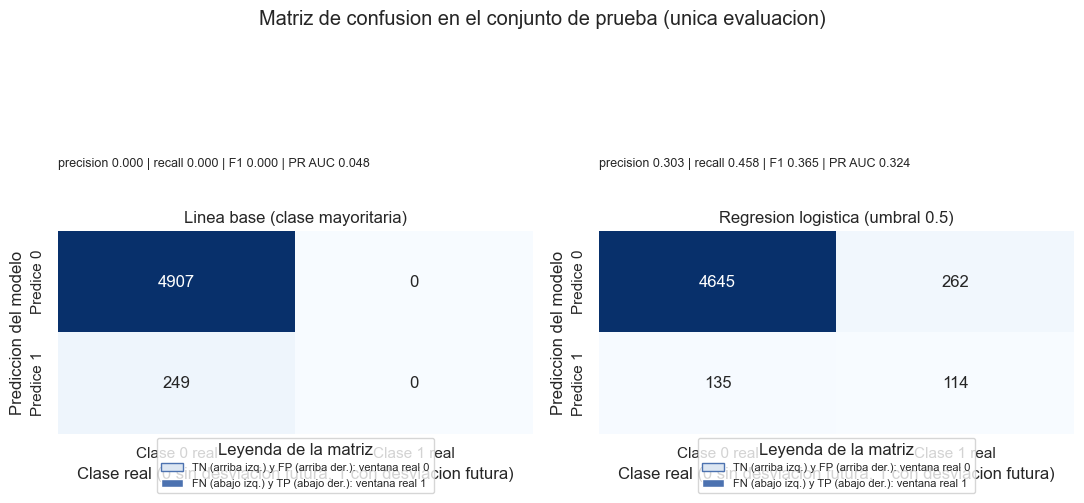

In [19]:
# --- Grafico 1: matrices de confusion (linea base y modelo principal).
fig, axes = plt.subplots(1, 2, figsize=config['visual']['figsize'])
for ax, (nombre, resultado) in zip(axes, [
        ('Linea base (clase mayoritaria)', resultado_base),
        ('Regresion logistica (umbral %s)' % config['umbral_inicial'], resultado_modelo)]):
    matriz = np.array([[resultado['tn'], resultado['fp']],
                       [resultado['fn'], resultado['tp']]])
    sns.heatmap(matriz, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Clase 0 real', 'Clase 1 real'],
                yticklabels=['Predice 0', 'Predice 1'])
    ax.set_title(nombre)
    ax.set_xlabel('Clase real (0 sin desviacion futura, 1 con desviacion futura)')
    ax.set_ylabel('Prediccion del modelo')
    ax.text(0.0, 1.32, 'precision %.3f | recall %.3f | F1 %.3f | PR AUC %.3f'
            % (resultado['precision'], resultado['recall'], resultado['f1'],
               resultado['pr_auc']),
            transform=ax.transAxes, fontsize=9)
    ax.legend(handles=[mpatches.Patch(facecolor='#DCE6F2', edgecolor='#4C72B0',
                                      label='TN (arriba izq.) y FP (arriba der.): ventana real 0'),
                       mpatches.Patch(facecolor='#4C72B0',
                                      label='FN (abajo izq.) y TP (abajo der.): ventana real 1')],
              title='Leyenda de la matriz', loc='lower center', bbox_to_anchor=(0.5, -0.32),
              fontsize=8)
fig.suptitle('Matriz de confusion en el conjunto de prueba (unica evaluacion)', y=1.04)
fig.tight_layout()
plt.show()

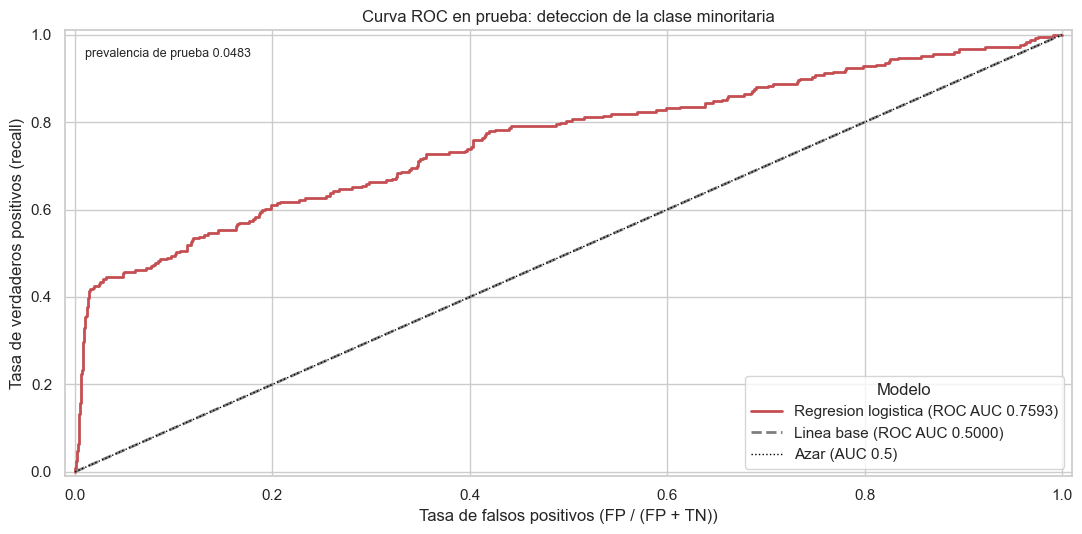

In [20]:
# --- Grafico 2: curva ROC del modelo principal y de la linea base.
fig, ax = plt.subplots(figsize=config['visual']['figsize'])
fpr, tpr, _ = roc_curve(y_te, prob_te)
fpr_b, tpr_b, _ = roc_curve(y_te, base_prob_te)
ax.plot(fpr, tpr, color=VIS['paleta'][1], lw=2,
        label='Regresion logistica (ROC AUC %.4f)' % resultado_modelo['roc_auc'])
ax.plot(fpr_b, tpr_b, color=VIS['paleta_base'], lw=2, ls='--',
        label='Linea base (ROC AUC %.4f)' % resultado_base['roc_auc'])
ax.plot([0, 1], [0, 1], color='black', lw=1, ls=':', label='Azar (AUC 0.5)')
ax.set_xlabel('Tasa de falsos positivos (FP / (FP + TN))')
ax.set_ylabel('Tasa de verdaderos positivos (recall)')
ax.set_title('Curva ROC en prueba: deteccion de la clase minoritaria')
ax.legend(loc='lower right', title='Modelo')
ax.set_xlim(-0.01, 1.01)
ax.set_ylim(-0.01, 1.01)
ax.text(0.02, 0.96, 'prevalencia de prueba %.4f' % float(y_te.mean()),
        transform=ax.transAxes, va='top', fontsize=9)
fig.tight_layout()
plt.show()

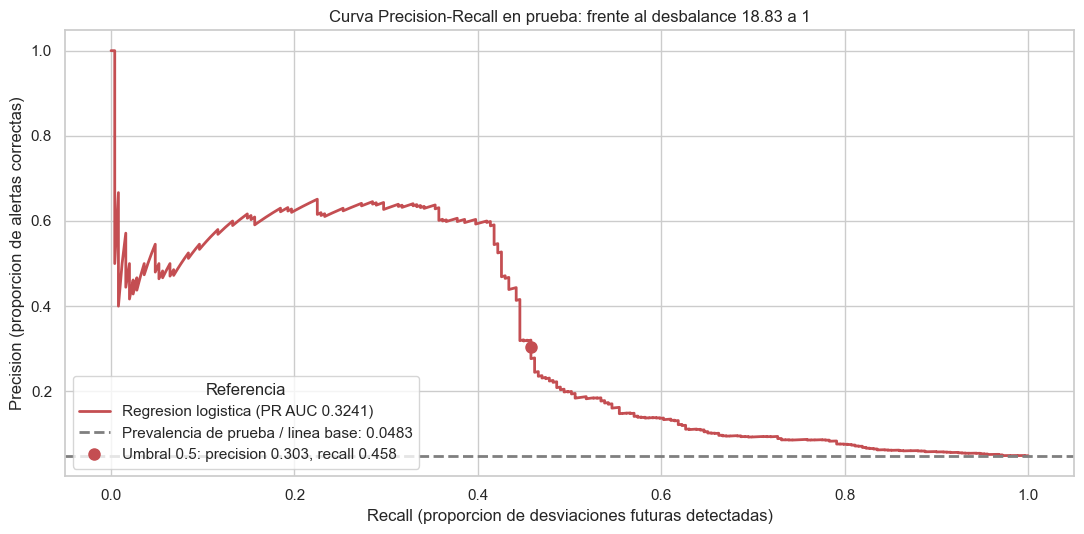

In [21]:
# --- Grafico 3: curva Precision-Recall con la referencia de prevalencia.
fig, ax = plt.subplots(figsize=config['visual']['figsize'])
precision, recall, _ = precision_recall_curve(y_te, prob_te)
ax.plot(recall, precision, color=VIS['paleta'][1], lw=2,
        label='Regresion logistica (PR AUC %.4f)' % resultado_modelo['pr_auc'])
ax.axhline(float(y_te.mean()), color=VIS['paleta_base'], ls='--', lw=2,
           label='Prevalencia de prueba / linea base: %.4f' % float(y_te.mean()))
ax.plot([resultado_modelo['recall']], [resultado_modelo['precision']], 'o',
        color=VIS['paleta'][1], ms=8,
        label='Umbral %s: precision %.3f, recall %.3f'
              % (config['umbral_inicial'], resultado_modelo['precision'],
                 resultado_modelo['recall']))
ax.set_xlabel('Recall (proporcion de desviaciones futuras detectadas)')
ax.set_ylabel('Precision (proporcion de alertas correctas)')
ax.set_title('Curva Precision-Recall en prueba: frente al desbalance 18.83 a 1')
ax.legend(loc='lower left', title='Referencia')
fig.tight_layout()
plt.show()

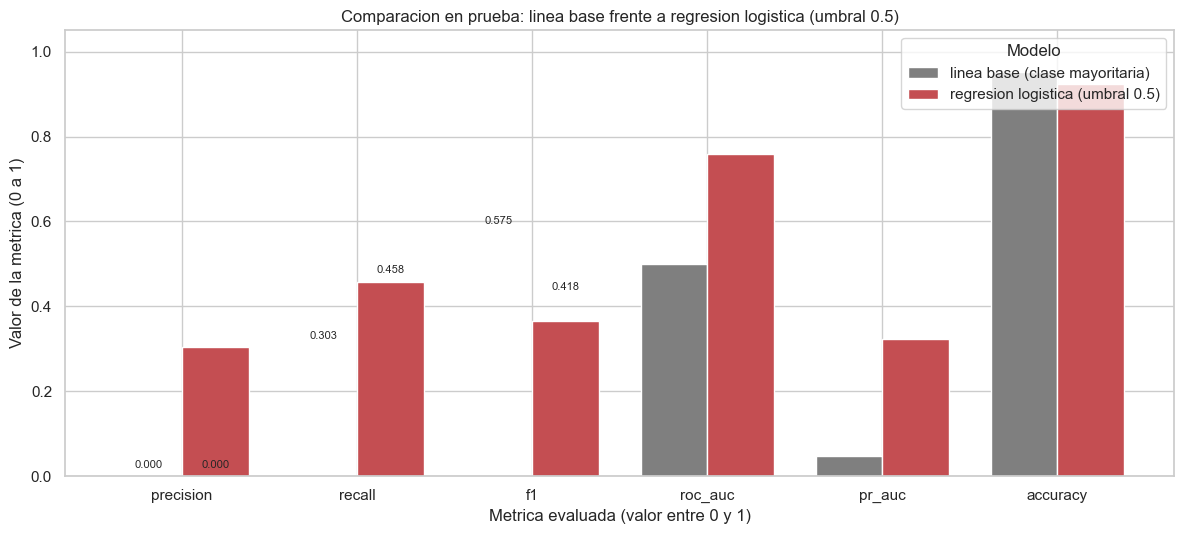

                                      modelo  precision  recall     f1  roc_auc  pr_auc  accuracy
              linea base (clase mayoritaria)     0.0000  0.0000 0.0000   0.5000  0.0483    0.9517
            regresion logistica (umbral 0.5)     0.3032  0.4578 0.3648   0.7593  0.3241    0.9230
regresion logistica (umbral secundario 0.57)     0.5746  0.4177 0.4837   0.7593  0.3241    0.9569

  PR AUC es la metrica principal: la linea base la tiene igual a la prevalencia,
  de modo que superar ese valor es la mejora minima demostrable.


In [22]:
# --- Grafico 4: comparacion tabular entre linea base y regresion logistica.
metricas_comparadas = ['precision', 'recall', 'f1', 'roc_auc', 'pr_auc', 'accuracy']
tabla_grafico = comparacion_prueba.set_index('modelo')[metricas_comparadas]
eje = np.arange(len(metricas_comparadas))
ancho = 0.38
fig, ax = plt.subplots(figsize=(12, 5.5))
ax.bar(eje - ancho / 2, tabla_grafico.iloc[0].values, ancho,
       color=VIS['paleta_base'], label=tabla_grafico.index[0])
ax.bar(eje + ancho / 2, tabla_grafico.iloc[1].values, ancho,
       color=VIS['paleta'][1], label=tabla_grafico.index[1])
ax.set_xticks(eje)
ax.set_xticklabels(metricas_comparadas)
ax.set_xlabel('Metrica evaluada (valor entre 0 y 1)')
ax.set_ylabel('Valor de la metrica (0 a 1)')
ax.set_ylim(0, 1.05)
ax.set_title('Comparacion en prueba: linea base frente a regresion logistica '
             '(umbral %s)' % config['umbral_inicial'])
ax.legend(title='Modelo', loc='upper right')
for posicion, (nombre, fila) in enumerate(tabla_grafico.iterrows()):
    for offset, valor in zip([-ancho / 2, ancho / 2], fila.values):
        ax.text(posicion + offset, valor + 0.02, '%.3f' % valor, ha='center', fontsize=8)
fig.tight_layout()
plt.show()
print(comparacion_prueba[['modelo'] + metricas_comparadas].round(4).to_string(index=False))
print()
print('  PR AUC es la metrica principal: la linea base la tiene igual a la prevalencia,')
print('  de modo que superar ese valor es la mejora minima demostrable.')

INTERPRETACION DE COEFICIENTES (log-odds y odds ratio, IC 95 % aproximado)
  Sayas escaladas en desviaciones estandar; banderas e indicadores en su escala
  original 0/1. Errores estandar calculados con la informacion de Fisher sobre
  entrenamiento. Una correlacion de 0.99 entre temperatura actual y anterior
  impide repartir el merito entre ambas variables.
                               feature  coeficiente  error  ic_inf  ic_sup  odds_ratio  or_ic_inf  or_ic_sup
indicador__sin_historial_temp_anterior      -1.0596 0.2456 -1.5410 -0.5782      0.3466     0.2142     0.5609
        continuo__temperatura_anterior      -0.2039 1.3591 -2.8677  2.4599      0.8156     0.0568    11.7035
        indicador__sin_historial_var30      -0.1905 0.1773 -0.5380  0.1569      0.8265     0.5839     1.1699
 continuo__variacion_temperatura_30min       0.0161 0.1981 -0.3723  0.4044      1.0162     0.6892     1.4985
        continuo__temperatura_cabina_c       0.0289 1.3595 -2.6356  2.6935      1.0293     0.

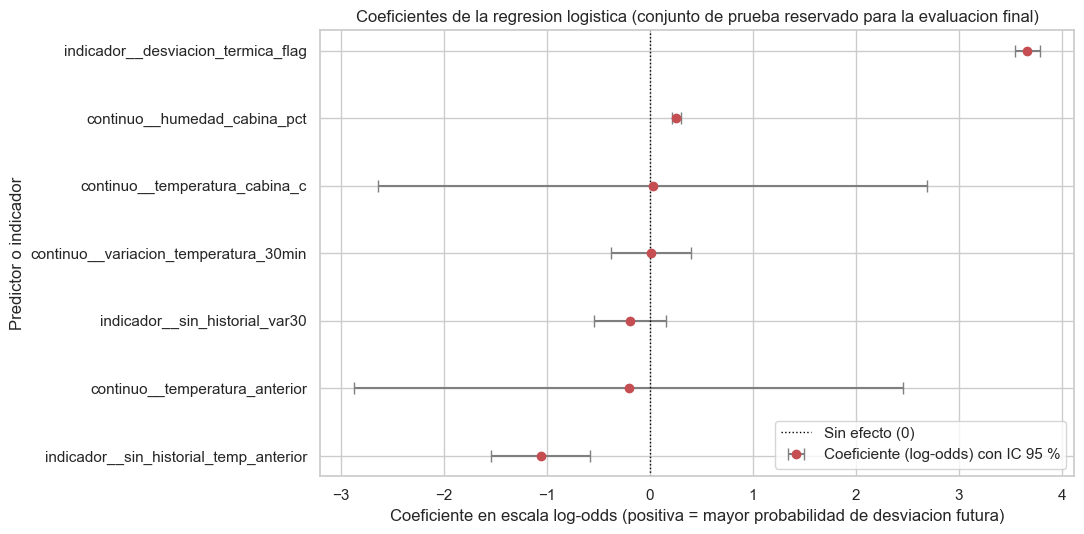

In [23]:
# --- Grafico 5: coeficientes y odds ratios con intervalo de confianza al 95 %.
X_tr_pre = pipeline.named_steps['preprocesador'].transform(X_tr)
nombres = [str(n) for n in pipeline.named_steps['preprocesador'].get_feature_names_out()]
probabilidades_tr = pipeline.predict_proba(X_tr)[:, 1]
pesos = X_tr_pre * (y_tr.to_numpy() - probabilidades_tr)[:, None]
H = pesos.T @ pesos + 1e-12
cov = np.linalg.pinv(H)
errores = np.sqrt(np.clip(np.diag(cov), 0, None))
ic_inf = modelo.coef_[0] - 1.959964 * errores
ic_sup = modelo.coef_[0] + 1.959964 * errores

tabla_ic = pd.DataFrame({
    'feature': nombres,
    'coeficiente': modelo.coef_[0],
    'error': errores,
    'ic_inf': ic_inf,
    'ic_sup': ic_sup,
    'odds_ratio': np.exp(modelo.coef_[0]),
    'or_ic_inf': np.exp(ic_inf),
    'or_ic_sup': np.exp(ic_sup),
}).sort_values('coeficiente')

print('INTERPRETACION DE COEFICIENTES (log-odds y odds ratio, IC 95 % aproximado)')
print('  Sayas escaladas en desviaciones estandar; banderas e indicadores en su escala')
print('  original 0/1. Errores estandar calculados con la informacion de Fisher sobre')
print('  entrenamiento. Una correlacion de 0.99 entre temperatura actual y anterior')
print('  impide repartir el merito entre ambas variables.')
print(tabla_ic.round(4).to_string(index=False))
print()
print('  CALIBRACION: class_weight="balanced" reescala la frontera de decision, de modo')
print('  que las probabilidades de salida NO estan calibradas. Un valor de 0.6 no debe')
print('  leerse como un 60 % verificado de probabilidad de desviacion, sino como un')
print('  puntaje de priorizacion. Por eso el umbral se fija con validacion sobre datos y')
print('  no leyendo probabilidades, y con una curva de fiabilidad si se quiere usar la')
print('  salida como estimacion de riesgo.')
print()
print('  Un coeficiente no es un efecto causal ni una importancia de negocio: solo')
print('  describe la asociacion ajustada dentro del modelo, con el resto de')
print('  predictores constante, sobre ventanas de lectura de un unico mes.')

fig, ax = plt.subplots(figsize=(11, 5.5))
posiciones = np.arange(len(tabla_ic))
ax.errorbar(tabla_ic['coeficiente'], posiciones,
            xerr=1.959964 * tabla_ic['error'],
            fmt='o', color=VIS['paleta'][1], ecolor=VIS['paleta_base'], capsize=4,
            label='Coeficiente (log-odds) con IC 95 %')
ax.axvline(0, color='black', ls=':', lw=1, label='Sin efecto (0)')
ax.set_yticks(posiciones)
ax.set_yticklabels(tabla_ic['feature'])
ax.set_xlabel('Coeficiente en escala log-odds (positiva = mayor probabilidad de desviacion futura)')
ax.set_ylabel('Predictor o indicador')
ax.set_title('Coeficientes de la regresion logistica (conjunto de prueba reservado para la evaluacion final)')
ax.legend(loc='lower right')
fig.tight_layout()
plt.show()

## 14. Controles finales

Los controles demuestran la integridad de la poblacion, la separacion por grupos, la
ausencia de fuga temporal, el ajuste del preprocesamiento solo con entrenamiento y la
existencia de la comparacion con la linea base.

In [24]:
# --- Controles finales: todos deben quedar en OK.
controles = []


def registrar(nombre, condicion, detalle=''):
    controles.append({'control': nombre, 'ok': bool(condicion), 'detalle': detalle})


HASH_GOLD_CIERRE = hashlib.sha256(PATHS['gold'].read_bytes()).hexdigest()
registrar('Gold no modificado (SHA-256 identico al inicio y al cierre)',
          HASH_GOLD_ENTRADA == HASH_GOLD_CIERRE, HASH_GOLD_CIERRE)
registrar('Forma Gold 28448 x 20', gold.shape == (28448, 20), str(gold.shape))
registrar('Clave de lectura unica (viaje_id + timestamp)',
          int(gold.duplicated(clave).sum()) == 0)
registrar('Poblacion: 25777 modeladas + 2671 no evaluables = 28448',
          len(poblacion) + int((gold[ventana] == False).sum()) == len(gold),
          '%d + %d = %d' % (len(poblacion), int((gold[ventana] == False).sum()), len(gold)))
registrar('No se uso dropna: la poblacion se filtra por la bandera y por el objetivo',
          len(poblacion) == int((gold[ventana] == True).sum()))
registrar('Objetivo nulo solo en ventanas no evaluables',
          bool(gold.loc[gold[ventana] == False, objetivo].isna().all())
          and bool(gold.loc[gold[ventana] == True, objetivo].notna().all()))
registrar('Objetivo contiene solo 0 y 1 en la poblacion de modelado',
          sorted(poblacion['y'].unique()) == [0, 1])
registrar('Exclusiones contadas por causa y documentadas',
          sum(exclusiones.values()) == int((gold[ventana] == False).sum()), str(exclusiones))
registrar('Filas usadas para modelado', len(modelado) == 25777, str(len(modelado)))
registrar('Grupos totales de la poblacion', modelado[entidad].nunique() == 1200,
          str(modelado[entidad].nunique()))
registrar('Proporcion de prueba aproximadamente la configurada',
          abs(len(X_te) / len(X) - config['test_size']) < 0.01,
          'real %.4f vs config %.2f' % (len(X_te) / len(X), config['test_size']))
registrar('Grupos de entrenamiento y de prueba con ambas clases',
          sorted(set(y_tr.unique())) == [0, 1] and sorted(set(y_te.unique())) == [0, 1],
          'tr %s / te %s' % ([int(v) for v in sorted(set(y_tr.unique()))],
                              [int(v) for v in sorted(set(y_te.unique()))]))
registrar('Interseccion de grupos entre entrenamiento y prueba vacia',
          interseccion == set(), str(len(interseccion)))
registrar('Ninguna lectura de prueba aparece en entrenamiento',
          int(modelado.iloc[idx_te].set_index(clave).index.isin(
              modelado.iloc[idx_tr].set_index(clave).index).sum()) == 0)
registrar('Predictores = 5 minimos + 2 indicadores de ausencia',
          len(PREDICTORES) == 7 and set(PRED) <= set(modelado.columns), str(PREDICTORES))
registrar('Predictores disjuntos de objetivo, bandera, identificadores, timestamp y auditoria',
          len(set(PREDICTORES) & set(config['columnas_no_admisibles'])) == 0)
registrar('El objetivo no esta dentro de X', objetivo not in X.columns)
registrar('No hay variables posteriores a t en X',
          COL['ts_temp_anterior'] not in X.columns and COL['ts_base_var'] not in X.columns)
ts_t = pd.to_datetime(antes[ts_col], utc=True)
ts_ta = pd.to_datetime(antes[COL['ts_temp_anterior']], utc=True)
ts_var = pd.to_datetime(antes[COL['ts_base_var']], utc=True)
registrar('Antecedentes temporales nunca posteriores al instante de prediccion',
          bool((ts_ta.dropna() <= ts_t[ts_ta.dropna().index]).all())
          and bool((ts_var.dropna() <= ts_t[ts_var.dropna().index]).all()))
registrar('Todo antecedente presente tiene marca de tiempo y viceversa',
          bool(ts_ta.isna().equals(antes[COL['temp_anterior']].isna()))
          and bool(ts_var.isna().equals(antes[COL['var_30min']].isna())))
registrar('La codificacion neutral se aplico solo a nulos estructurales declarados',
          motivo_ta_valido and motivo_var_valido)
registrar('Indicadores de ausencia creados para cada regla',
          int((modelado[IND[0]] == 1).sum()) == int(afectadas_ta.sum())
          and int((modelado[IND[1]] == 1).sum()) == int(afectadas_var.sum()),
          '%s = %d filas, %s = %d filas'
          % (IND[0], int(afectadas_ta.sum()), IND[1], int(afectadas_var.sum())))
registrar('Los residuales declarados se tratan dentro del Pipeline (mediana de entrenamiento)',
          sorted(residuales) == [COL['humedad_actual']]
          and len(imputador.statistics_) == len(imputador.feature_names_in_))
registrar('Imputacion y escalado aprendidos solo con entrenamiento',
          np.allclose(imputador.statistics_,
                      [X_tr[c].median() for c in imputador.feature_names_in_]),
          'medianas de train vs medianas de prueba: %s vs %s'
          % (np.round(medianas_tr, 4).tolist(), np.round(medianas_te, 4).tolist()))
registrar('Pipeline ajustado una sola vez y solo con X_tr (verificado, no afirmado)',
          len(AJUSTES_MODELO_PRINCIPAL) == 1
          and AJUSTES_MODELO_PRINCIPAL[0]['filas'] == len(X_tr)
          and AJUSTES_MODELO_PRINCIPAL[0]['columnas'] == X_tr.shape[1]
          and AJUSTES_MODELO_PRINCIPAL[0]['objeto'] == id(pipeline),
          str(AJUSTES_MODELO_PRINCIPAL))
registrar('Modelo sin advertencias de convergencia (n_iter < max_iter)',
          int(modelo.n_iter_[0]) < modelo.max_iter, 'n_iter %d' % int(modelo.n_iter_[0]))
registrar('Validacion cruzada por grupos sin solapes de viajes',
          all(cv_principal['filas'] > 0)
          and abs(cv_principal['filas'].sum() - len(y_tr)) == 0,
          'suma de filas por fold = %d' % int(cv_principal['filas'].sum()))
registrar('Metricas de linea base y de regresion logistica disponibles',
          all(clave in resultado_base and clave in resultado_modelo
              for clave in config['metricas'][:7]))
registrar('Accuracy no es la unica metrica reportada',
          len(config['metricas']) >= 7 and 'pr_auc' in config['metricas'])
registrar('Semilla fija declarada y usada en el split y en la validacion',
          config['semilla'] == SEMILLA and separador.random_state == config['semilla']
          and cv.random_state == config['semilla'], str(config['semilla']))
registrar('El conjunto de prueba se evaluo una sola vez por modelo (contador verificado)',
          EVALUACIONES_PRUEBA == {'modelo_principal': 1, 'linea_base': 1},
          str(EVALUACIONES_PRUEBA))
registrar('Las estadisticas descriptivas se resumen solo con filas de entrenamiento',
          len(X_tr) < len(X) and int(cv_principal['filas'].sum()) == len(X_tr),
          'filas de entrenamiento %d de %d; la tabla descriptiva usa X_tr'
          % (len(X_tr), len(X)))
registrar('La comparacion de ponderacion no se hizo con el conjunto de prueba',
          config['sensibilidad']['uso_del_conjunto_de_prueba'].startswith('ninguno')
          and config['sensibilidad']['criterio_principal'] == 'recall de la clase positiva'
          and config['sensibilidad']['metrica_global_no_unico_criterio'] is True,
          'criterio principal: %s' % config['sensibilidad']['criterio_principal'])
registrar('Se exporta un unico CSV de metricas y no se escribe el Gold',
          PATHS['metricas_csv'].exists() and hashlib.sha256(PATHS['gold'].read_bytes())
          .hexdigest() == HASH_GOLD_ENTRADA,
          PATHS['metricas_csv'].relative_to(RAIZ).as_posix())

tabla_controles = pd.DataFrame(controles)
print('CONTROLES FINALES')
print(tabla_controles.to_string(index=False))
print()
print('  Controles en OK:', int(tabla_controles['ok'].sum()), 'de', len(tabla_controles))
print('  Controles en fallo:', int((~tabla_controles['ok']).sum()))
if not tabla_controles['ok'].all():
    raise AssertionError('Hay controles finales en fallo: '
                         + ', '.join(tabla_controles.loc[~tabla_controles['ok'], 'control']))
print('  Todos los controles finales quedaron en OK.')

CONTROLES FINALES
                                                                           control   ok                                                                                                                                                                                detalle
                       Gold no modificado (SHA-256 identico al inicio y al cierre) True                                                                                                                       f0194aae8dfe9073fd0e5bbf14cb72353a02863915e483ceec66027e81406479
                                                             Forma Gold 28448 x 20 True                                                                                                                                                                            (28448, 20)
                                     Clave de lectura unica (viaje_id + timestamp) True                                                                                  

## 15. Reproducibilidad

Interprete, versiones, semilla, rutas y cifras de referencia para redactar el informe. El
notebook no escribe el Gold ni exporta archivos de datos: su unico producto, ademas del
informe MD, es el propio notebook ejecutado.

In [25]:
# --- Reproducibilidad y cifras de referencia para el informe.
print('REPRODUCIBILIDAD')
print('  Ejecucion UTC:', datetime.now(timezone.utc).isoformat())
print('  Interprete:', sys.executable)
print('  Python:', platform.python_version())
print('  pandas:', pd.__version__, '| numpy:', np.__version__,
      '| scikit-learn:', sklearn.__version__, '| seaborn:', sns.__version__,
      '| matplotlib:', matplotlib.__version__)
print('  Semilla unica en config:', config['semilla'])
print('  Split:', 'GroupShuffleSplit(n_splits=1, test_size=%s, random_state=%s)'
      % (config['test_size'], config['semilla']))
print('  Validacion: StratifiedGroupKFold(n_splits=%s, shuffle=True, random_state=%s)'
      % (config['n_splits_validacion'], config['semilla']))
print('  Modelo principal: LogisticRegression(%s)' % config['logistic_regression'])
print('  Umbral de referencia:', config['umbral_inicial'],
      '| umbral secundario out-of-fold:', round(umbral_f2, 4))
print('  Deteccion de raiz: variable ANDINALOG_ROOT o ancestros del directorio actual.')
print('  El notebook se ejecuta de arriba abajo, sin estado oculto y sin variables')
print('  creadas fuera de el. No escribe el Gold; su unico archivo exportado es el CSV')
print('  de metricas declarado en config.')
print('  Criterios de seleccion declarados: criterio principal =',
      config['sensibilidad']['criterio_principal'], '| restriccion operativa =',
      ', '.join(config['sensibilidad']['restriccion_operativa']),
      '| metrica global complementaria =', config['sensibilidad']['metrica_global_complementaria'],
      '| modelo principal =', config['sensibilidad']['modelo_principal'],
      '| alternativa =', config['sensibilidad']['alternativa_operativa'])
print('  Uso del conjunto de prueba en la comparacion:',
      config['sensibilidad']['uso_del_conjunto_de_prueba'])
print()
print('  CIFRAS PARA EL INFORME')
print('   Filas Gold:', len(gold), '| columnas:', gold.shape[1])
print('   Ventanas evaluables:', int((gold[ventana] == True).sum()),
      '| no evaluables:', int((gold[ventana] == False).sum()))
print('   Filas de modelado:', len(modelado), '| viajes:', int(modelado[entidad].nunique()))
print('   Positivos:', int(modelado['y'].sum()), '| negativos:',
      int((modelado['y'] == 0).sum()), '| prevalencia:', round(prevalencia, 6))
print('   Filas con', IND[0], '= 1:', int((modelado[IND[0]] == 1).sum()))
print('   Filas con', IND[1], '= 1:', int((modelado[IND[1]] == 1).sum()))
print('   Faltantes residuales de humedad:', int(modelado[COL['humedad_actual']].isna().sum()))
print('   Entrenamiento:', len(X_tr), 'filas /', len(grupos_tr), 'viajes /',
      int(y_tr.sum()), 'positivos')
print('   Prueba:', len(X_te), 'filas /', len(grupos_te), 'viajes /',
      int(y_te.sum()), 'positivos')
print('   Interseccion de grupos:', len(interseccion))
print('   Recall medio en CV, criterio principal: balanced',
      round(float(cv_principal['recall'].mean()), 6),
      '| sin ponderar:', round(float(cv_sin_ponderar['recall'].mean()), 6))
print('   Precision media en CV, restriccion operativa: balanced',
      round(float(cv_principal['precision'].mean()), 6),
      '| sin ponderar:', round(float(cv_sin_ponderar['precision'].mean()), 6))
print('   Alertas por fold en CV: balanced',
      round(float(comparacion_b.loc[0, 'alertas_por_fold']), 1),
      '| sin ponderar:', round(float(comparacion_b.loc[1, 'alertas_por_fold']), 1))
print('   PR AUC medio en CV, metrica global complementaria: balanced',
      round(float(cv_principal['pr_auc'].mean()), 6),
      '| sin ponderar:', round(float(cv_sin_ponderar['pr_auc'].mean()), 6),
      '| historia completa:', round(float(cv_restringida['pr_auc'].mean()), 6))
print('   Prueba -> base PR AUC %.6f, recall %.6f'
      % (resultado_base['pr_auc'], resultado_base['recall']))
print('   Prueba -> modelo PR AUC %.6f, ROC AUC %.6f, precision %.6f, recall %.6f, F1 %.6f'
      % (resultado_modelo['pr_auc'], resultado_modelo['roc_auc'],
         resultado_modelo['precision'], resultado_modelo['recall'], resultado_modelo['f1']))
print('   Prueba -> modelo con umbral secundario %.4f: precision %.6f, recall %.6f, F1 %.6f'
      % (umbral_f2, resultado_modelo_f2['precision'], resultado_modelo_f2['recall'],
         resultado_modelo_f2['f1']))
print('   Graficos generados: 5')
print('   CSV de metricas exportado:', PATHS['metricas_csv'].relative_to(RAIZ).as_posix(),
      '| filas:', len(metricas_csv))
print('   Controles finales en OK:', int(tabla_controles['ok'].sum()), 'de',
      len(tabla_controles))
print('   Hash del Gold leido:', HASH_GOLD_CIERRE)
print()
print('  Rutas de los entregables:')
for clave in ('notebook', 'informe'):
    print('   ', config['rutas'][clave])

REPRODUCIBILIDAD
  Ejecucion UTC: 2026-09-25T21:04:09.730518+00:00
  Interprete: C:\Users\remrodri\Github\practicasNotebookColab\.venv\Scripts\python.exe
  Python: 3.13.15
  pandas: 3.0.5 | numpy: 2.5.3 | scikit-learn: 1.6.1 | seaborn: 0.13.2 | matplotlib: 3.10.0
  Semilla unica en config: 20260925
  Split: GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=20260925)
  Validacion: StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=20260925)
  Modelo principal: LogisticRegression({'penalty': 'l2', 'C': 1.0, 'solver': 'lbfgs', 'max_iter': 2000, 'random_state': 20260925, 'class_weight': 'balanced'})
  Umbral de referencia: 0.5 | umbral secundario out-of-fold: 0.57
  Deteccion de raiz: variable ANDINALOG_ROOT o ancestros del directorio actual.
  El notebook se ejecuta de arriba abajo, sin estado oculto y sin variables
  creadas fuera de el. No escribe el Gold; su unico archivo exportado es el CSV
  de metricas declarado en config.
  Criterios de seleccion declarados: criter